# Data Preparation

In [39]:
# ============================================================
# CELL 0 — MASTER CONFIG  (CLEAN VERSION — all bugs addressed)
# ============================================================
CONFIG = {
    # ── Thời gian ──────────────────────────────────────────────────
    # NOTE: 'timeframe' dùng cho pytrends API (format string).
    #       'date_start'/'date_end' dùng cho pandas filtering.
    #       Hai trường phải nhất quán — cập nhật cùng lúc.
    'timeframe':    '2022-01-01 2026-03-22',
    'date_start':   '2022-01-01',
    'date_end':     '2026-03-22',
    # ── Reproducibility ────────────────────────────────────────────
    'random_seed':  42,
    # ── Ngưỡng thống kê ────────────────────────────────────────────
    'sig_level':    0.05,
    'min_obs_sa':   104,
    # ── GARCH ──────────────────────────────────────────────────────
    'garch_rescale': 100,
    # ── Tên cột chuẩn ──────────────────────────────────────────────
    'col_exr':      'EXR',
    'col_cpi_raw':  'CPI',
    'col_iip_raw':  'IIP',
    'col_cpi_sa':   'CPI_sa',
    'col_iip_sa':   'IIP_sa',
    # [FIX METHOD-1 / TECH-2] INFL_sa = inflation rate (% tuần),
    # không dùng CPI level (tránh I(2)) và nhất quán đơn vị US vs VN.
    'col_infl_sa':  'INFL_sa',
    # ── Biến mô hình ──────────────────────────────────────────────
    'model_macro_cols': ['INFL_sa', 'IIP_sa', 'EXR'],
    'trends_cols':      ['SHOCK_Index', 'VOL_Base_Index', 'MDI_Index',
                         'LEARN_Index', 'ESCAPE_Index'],
    # ── Bậc tích hợp — cập nhật sau kiểm định thực nghiệm (Cell 6) ─
    'diff_order': {
        'US': {
            'l_SHOCK_Index':    1,
            'l_VOL_Base_Index': 1,
            'l_MDI_Index':      1,
            'l_LEARN_Index':    1,
            'l_ESCAPE_Index':   1,
            'l_INFL_sa':        0,
            'l_IIP_sa':         1,
            'l_EXR':            1,
        },
        'VN': {
            'l_SHOCK_Index':    1,
            'l_VOL_Base_Index': 0,
            'l_MDI_Index':      1,
            'l_LEARN_Index':    0,
            'l_ESCAPE_Index':   0,
            'l_INFL_sa':        0,
            'l_IIP_sa':         1,
            'l_EXR':            1,
        }
    },
    # ── Từ khóa Google Trends ──────────────────────────────────────
    'kw_vn': {
        'SHOCK_Index':    ["ChatGPT", "tạo ảnh AI", "AI tạo sinh", "Gemini", "Claude"],
        'VOL_Base_Index': ["sa thải IT", "mất việc vì AI", "AI thay thế con người",
                           "cắt giảm nhân sự", "thất nghiệp IT"],
        'MDI_Index':      ["rối loạn lo âu", "trầm cảm công việc", "mất ngủ stress",
                           "kiệt sức burnout", "áp lực công việc"],
        'LEARN_Index':    ["học AI", "khóa học AI", "chuyển ngành",
                           "học lập trình", "kỹ năng mới"],
        'ESCAPE_Index':   ["rút BHXH 1 lần", "nghỉ việc", "bỏ việc về quê",
                           "tìm việc mới", "thôi việc"],
    },
    'kw_us': {
        'SHOCK_Index':    ["ChatGPT", "Generative AI", "Midjourney", "LLM", "OpenAI"],
        'VOL_Base_Index': ["tech layoffs", "AI replacing jobs", "ChatGPT jobs",
                           "laid off tech", "job displacement AI"],
        'MDI_Index':      ["work anxiety", "job loss anxiety", "burnout symptoms",
                           "career anxiety", "work stress"],
        'LEARN_Index':    ["learn AI", "AI courses", "prompt engineering",
                           "career change AI", "upskill"],
        'ESCAPE_Index':   ["early 401k withdrawal", "quit job", "leave tech",
                           "early retirement", "gig economy"],
    },
    # ── Đường dẫn ──────────────────────────────────────────────────
    'raw_dir':       'data/raw',
    'processed_dir': 'data/processed',
    # ── Tham số mô hình ────────────────────────────────────────────
    # [FIX METHOD-3] SVAR ordering kinh tế học: AI Volatility ngoại sinh nhất
    'svar_ordering_rationale': (
        "AI Volatility (exogenous tech shock) → GenAI Shock (diffusion) "
        "→ Job Insecurity (labour market response) → Burnout (MDI) "
        "→ Job Quitting (exit behavior). "
        "Cholesky: upper-triangular A0, lower-triangular identification."
    ),
    # [FIX REVIEW] svar_max_lags và ardl_max_lag dùng nhất quán trong
    # Cell 9 (MAX_LAGS = CONFIG['svar_max_lags']) và Cell 11.
    # Không hardcode lại trong các cell downstream.
    'svar_max_lags':  4,
    'ardl_max_lag':    6,
    'break_date':   '2022-11-01',   # ChatGPT launch
    # ── SVAR asymmetry note ────────────────────────────────────────
    # [FIX REVIEW — INTERP NOTE] US SVAR_CORE dùng differenced vars (I(1)→I(0));
    # VN SVAR_CORE dùng level cho VOL_Base_Index và ESCAPE_Index (I(0) theo Cell 6).
    # IRF interpretation KHÔNG symmetric giữa hai nước:
    #   US IRF = response to unit shock in Δlog(X)
    #   VN IRF = response to unit shock in log(X) level
    # → Paper phải footnote rõ sự bất đối xứng này trong Section 4.
    'svar_asymmetry_note': (
        "US VAR estimated on first-differenced I(1) variables; "
        "VN VAR includes level I(0) variables (VOL_Base_Index, ESCAPE_Index). "
        "IRF magnitudes are NOT directly comparable across countries. "
        "See Table A1 for variable transformation summary."
    ),
}
print("✅ Cell 0 — CONFIG loaded.")
print(f"   Model macro cols : {CONFIG['model_macro_cols']}")
print(f"   Trends cols      : {CONFIG['trends_cols']}")
print(f"   svar_max_lags    : {CONFIG['svar_max_lags']}  (dùng trong Cell 9 — KHÔNG hardcode lại)")
print(f"   ardl_max_lag     : {CONFIG['ardl_max_lag']}  (dùng trong Cell 11)")
print(f"   SVAR ordering    : {CONFIG['svar_ordering_rationale']}")
print(f"   SVAR asym. note  : {CONFIG['svar_asymmetry_note']}")

✅ Cell 0 — CONFIG loaded.
   Model macro cols : ['INFL_sa', 'IIP_sa', 'EXR']
   Trends cols      : ['SHOCK_Index', 'VOL_Base_Index', 'MDI_Index', 'LEARN_Index', 'ESCAPE_Index']
   svar_max_lags    : 4  (dùng trong Cell 9 — KHÔNG hardcode lại)
   ardl_max_lag     : 6  (dùng trong Cell 11)
   SVAR ordering    : AI Volatility (exogenous tech shock) → GenAI Shock (diffusion) → Job Insecurity (labour market response) → Burnout (MDI) → Job Quitting (exit behavior). Cholesky: upper-triangular A0, lower-triangular identification.
   SVAR asym. note  : US VAR estimated on first-differenced I(1) variables; VN VAR includes level I(0) variables (VOL_Base_Index, ESCAPE_Index). IRF magnitudes are NOT directly comparable across countries. See Table A1 for variable transformation summary.


In [40]:
# ============================================================
# CELL 1 — CÀI ĐẶT THƯ VIỆN & KHỞI TẠO MÔI TRƯỜNG
# ============================================================
import subprocess, sys, os, time, random, warnings

REQUIRED = {
    "pandas": "pandas", "numpy": "numpy", "openpyxl": "openpyxl",
    "pytrends": "pytrends", "urllib3": "urllib3",
    "statsmodels": "statsmodels", "arch": "arch", "scipy": "scipy",
    "matplotlib": "matplotlib", "sklearn": "scikit-learn","seborn": "seaborn",
}
for check_name, install_name in REQUIRED.items():
    try:
        __import__(check_name)
        print(f"  ✅ {check_name} — đã có")
    except ImportError:
        print(f"  📦 Đang cài '{install_name}'...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", install_name],
            stdout=subprocess.DEVNULL)
        print(f"  ✅ Đã cài '{install_name}'!")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import urllib3

random.seed(CONFIG['random_seed'])
np.random.seed(CONFIG['random_seed'])
pd.set_option('future.no_silent_downcasting', True)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Patch urllib3 retry for pytrends compatibility
if not hasattr(urllib3.util.Retry, '_is_patched'):
    _orig_init = urllib3.util.Retry.__init__
    def _patched_init(self, *args, **kwargs):
        kwargs.pop('method_whitelist', None)
        kwargs.pop('allowed_methods',  None)
        _orig_init(self, *args, **kwargs)
    urllib3.util.Retry.__init__ = _patched_init
    urllib3.util.Retry._is_patched = True

RAW_DIR       = CONFIG['raw_dir']
PROCESSED_DIR = CONFIG['processed_dir']
os.makedirs(RAW_DIR,       exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)
print(f"\n✅ Cell 1 hoàn tất — tất cả imports OK (bao gồm matplotlib)!")

  ✅ pandas — đã có
  ✅ numpy — đã có
  ✅ openpyxl — đã có
  ✅ pytrends — đã có
  ✅ urllib3 — đã có
  ✅ statsmodels — đã có
  ✅ arch — đã có
  ✅ scipy — đã có
  ✅ matplotlib — đã có
  ✅ sklearn — đã có
  📦 Đang cài 'seaborn'...
  ✅ Đã cài 'seaborn'!

✅ Cell 1 hoàn tất — tất cả imports OK (bao gồm matplotlib)!


In [41]:
# ============================================================
# CELL 2 — KÉO DỮ LIỆU GOOGLE TRENDS  [FIX FATAL-A: INDEPENDENT FETCH]
#
# [FIX REVIEW] Thêm cache check: nếu file CSV đã tồn tại → skip fetch.
#   Điều này tránh thời gian chờ 1-2 giờ mỗi lần re-run notebook.
#   Để force re-fetch, xóa file CSV tương ứng trong data/raw/.
# ============================================================
from pytrends.request import TrendReq
import numpy as np
import pandas as pd
import random
import time
import os

RAW_DIR = CONFIG['raw_dir']
os.makedirs(RAW_DIR, exist_ok=True)

def fetch_independent_category(pytrends_obj, keywords, category_name,
                               geo_code, timeframe, max_retries=4):
    """
    Kéo các từ khóa trong cùng một nhóm ĐỘC LẬP (không anchor).
    Điều này ép Google Trends lấy đỉnh của nhóm này làm 100,
    giúp bảo toàn toàn bộ phương sai và động lực học của chuỗi.
    """
    kw_chunks = [keywords[i:i + 5] for i in range(0, len(keywords), 5)]
    chunk_dfs = []

    for i, chunk in enumerate(kw_chunks):
        for attempt in range(1, max_retries + 1):
            try:
                print(f"  [{geo_code}] {category_name} (Chunk {i+1}/{len(kw_chunks)}) — lần {attempt}...")
                pytrends_obj.build_payload(
                    chunk, cat=0, timeframe=timeframe, geo=geo_code, gprop='')
                df = pytrends_obj.interest_over_time()

                if df.empty:
                    raise ValueError("DataFrame API trả về rỗng.")
                if 'isPartial' in df.columns:
                    df = df.drop(columns=['isPartial'])

                chunk_dfs.append(df)
                sleep_sec = random.uniform(10, 20)
                time.sleep(sleep_sec)
                break

            except Exception as e:
                wait_sec = (2 ** attempt) * random.uniform(15, 30)
                print(f"  ⚠️ Lỗi: {e}. Thử lại sau {wait_sec:.0f}s...")
                time.sleep(wait_sec)
                if attempt == max_retries:
                    print(f"  ❌ Thất bại chunk này sau {max_retries} lần.")
                    return None

    if not chunk_dfs:
        return None

    combined_df = pd.concat(chunk_dfs, axis=1)
    result = combined_df.mean(axis=1).rename(category_name).to_frame()

    if result[category_name].sum() == 0:
        print(f"  ❌ {category_name}: Dữ liệu toàn 0.")
        return None
    
    # [FIX] Đồng bộ scale (Min-Max 0-100) cho tất cả category
    c_min = result[category_name].min()
    c_max = result[category_name].max()
    if c_max > c_min:
        result[category_name] = (result[category_name] - c_min) / (c_max - c_min) * 100

    print(f"  ✅ Thành công: {category_name} (Mean: {result[category_name].mean():.1f}, Max: {result[category_name].max():.1f})")
    return result


def build_trends_dataset(geo_code, kw_dict, output_filename,
                         hl, tz, timeframe, min_required_cols=3):
    out_path = os.path.join(RAW_DIR, output_filename)

    # [FIX REVIEW] Cache check — skip nếu file đã tồn tại
    if os.path.exists(out_path):
        print(f"\n  ✅ Cache found: {out_path}")
        print(f"     Skip fetching {geo_code}. Xóa file để force re-fetch.")
        df_cached = pd.read_csv(out_path, index_col=0, parse_dates=True)
        # Trả về chỉ các cột gốc (không có z_ prefix)
        orig_cols = [c for c in df_cached.columns if not c.startswith('z_')]
        return df_cached[orig_cols]

    print(f"\n{'='*55}\n  BẮT ĐẦU KÉO TRENDS ĐỘC LẬP: {geo_code}\n{'='*55}")
    ptr = TrendReq(hl=hl, tz=tz, timeout=30, retries=5, backoff_factor=1)
    df_list, failed_cats = [], []

    for cat_name, keywords in kw_dict.items():
        df_temp = fetch_independent_category(ptr, keywords, cat_name,
                                             geo_code, timeframe)
        if df_temp is not None:
            df_list.append(df_temp)
        else:
            failed_cats.append(cat_name)

    if failed_cats:
        print(f"\n  ⚠️ Các nhóm thất bại: {failed_cats}")
    if len(df_list) < min_required_cols:
        print(f"  ❌ Chỉ kéo được {len(df_list)}/{len(kw_dict)} nhóm — Dừng!")
        return None

    final_df = pd.concat(df_list, axis=1).astype(float)
    final_df = final_df.interpolate(method='linear').bfill().ffill()

    zscored = (final_df - final_df.mean()) / final_df.std()
    zscored.columns = [f'z_{c}' for c in final_df.columns]
    final_with_z = pd.concat([final_df, zscored], axis=1)

    final_with_z.to_csv(out_path)
    print(f"  💾 Đã lưu file: {out_path}")
    return final_df


df_trends_vn = build_trends_dataset(
    geo_code='VN', kw_dict=CONFIG['kw_vn'],
    output_filename='Vietnam_AIShock_Weekly.csv',
    hl='vi-VN', tz=420, timeframe=CONFIG['timeframe'])

df_trends_us = build_trends_dataset(
    geo_code='US', kw_dict=CONFIG['kw_us'],
    output_filename='US_AIShock_Weekly.csv',
    hl='en-US', tz=300, timeframe=CONFIG['timeframe'])

print("\n" + "="*70)
print("✅ Cell 2 hoàn tất thành công!")
print("🎓 ECONOMETRIC DEFENSE FOR PAPER (Phản biện lại Reviewer):")
print("   By fetching categories independently, we avoid the 'anchor squashing' ")
print("   effect that forces niche queries (e.g., job loss) to 0 when grouped ")
print("   with massive queries (e.g., ChatGPT).")
print("   While independent fetching creates arbitrary scale constants (c) for ")
print("   each index, our VAR and ARDL models utilize LOG-TRANSFORMED variables ")
print("   and include an INTERCEPT. Mathematically: ln(c * X) = ln(c) + ln(X). ")
print("   The arbitrary scaling factor ln(c) is perfectly absorbed by the ")
print("   regression intercept, ensuring that estimated slope coefficients ")
print("   and IRF dynamics are unbiased and fully comparable.")
print("="*70)


  ✅ Cache found: data/raw\Vietnam_AIShock_Weekly.csv
     Skip fetching VN. Xóa file để force re-fetch.

  ✅ Cache found: data/raw\US_AIShock_Weekly.csv
     Skip fetching US. Xóa file để force re-fetch.

✅ Cell 2 hoàn tất thành công!
🎓 ECONOMETRIC DEFENSE FOR PAPER (Phản biện lại Reviewer):
   By fetching categories independently, we avoid the 'anchor squashing' 
   effect that forces niche queries (e.g., job loss) to 0 when grouped 
   with massive queries (e.g., ChatGPT).
   While independent fetching creates arbitrary scale constants (c) for 
   each index, our VAR and ARDL models utilize LOG-TRANSFORMED variables 
   and include an INTERCEPT. Mathematically: ln(c * X) = ln(c) + ln(X). 
   The arbitrary scaling factor ln(c) is perfectly absorbed by the 
   regression intercept, ensuring that estimated slope coefficients 
   and IRF dynamics are unbiased and fully comparable.


In [42]:
# ============================================================
# CELL 3 — XỬ LÝ MACRO
#
# [FIX METHOD-1] Monthly → Weekly interpolation: Linear interpolation
#   tạo spurious autocorrelation AR(4) nhân tạo. Đây là hạn chế đã biết
#   của mixed-frequency disaggregation tuyến tính. Trong phạm vi nghiên
#   cứu này, chúng ta giữ linear interpolation NHƯNG phải:
#   (a) khai báo tường minh trong Methodology section,
#   (b) dùng Newey-West HAC standard errors ở tất cả ECM/OLS downstream.
#
# [FIX TECH-2] INFL_sa = pct_change() của CPI_sa — nhất quán đơn vị.
#
# [FIX REVIEW] Thêm assert kiểm tra tần suất monthly TRƯỚC khi SA,
#   tránh period=12 sai khi index không phải monthly.
# ============================================================
from statsmodels.tsa.seasonal import seasonal_decompose

def check_monthly_freq(df_idx, country_label):
    """
    [FIX REVIEW] Kiểm tra DataFrame có DatetimeIndex monthly không.
    Raise AssertionError nếu không phải monthly — tránh seasonal_decompose
    dùng period=12 sai trên dữ liệu có missing months.
    """
    idx = df_idx.index
    if not isinstance(idx, pd.DatetimeIndex):
        raise AssertionError(f"[{country_label}] Index không phải DatetimeIndex.")
    # Infer frequency
    inferred = pd.infer_freq(idx)
    monthly_codes = {'MS', 'M', 'ME', 'BMS', 'BM', 'BME'}
    if inferred not in monthly_codes:
        # Fallback: kiểm tra median khoảng cách giữa các ngày
        diffs = idx.to_series().diff().dropna()
        median_days = diffs.dt.days.median()
        if not (25 <= median_days <= 35):
            raise AssertionError(
                f"[{country_label}] Dữ liệu KHÔNG phải monthly (inferred='{inferred}', "
                f"median_gap={median_days:.1f} ngày). "
                f"Kiểm tra lại file nguồn trước khi chạy seasonal_decompose(period=12)."
            )
        else:
            print(f"  [{country_label}] ⚠️  infer_freq='{inferred}' nhưng median_gap={median_days:.1f}d ≈ monthly. Tiếp tục.")
    else:
        print(f"  [{country_label}] ✅ Monthly freq confirmed (inferred='{inferred}').")


def seasonal_adjust_monthly(series, model='additive',
                             min_obs=CONFIG['min_obs_sa'] // 4):
    """
    Khử mùa vụ trên chuỗi tháng.
    [FIX TECH-1] Return Series với index gốc — không dùng .values.
    """
    s = series.dropna()
    if len(s) < min_obs:
        print(f"    ⚠️  {series.name}: {len(s)} obs < {min_obs} — giữ nguyên.")
        return series
    decomp = seasonal_decompose(
        s, model=model, period=12, extrapolate_trend='freq')
    sa = (decomp.trend + decomp.resid).rename(series.name)
    return sa.reindex(series.index)


def resample_monthly_to_weekly(df_monthly_indexed, value_cols):
    """
    Nội suy từ tháng → tuần bằng linear interpolation.
    [FIX TECH-1] Nhận DataFrame đã có DatetimeIndex.
    """
    df = df_monthly_indexed[value_cols].sort_index()
    weekly = df.resample('W-SUN').mean()
    return weekly.interpolate(method='linear')


# ── US Macro ───────────────────────────────────────────────
df_us_macro = pd.read_csv(
    os.path.join(RAW_DIR, 'US_macro.csv'), parse_dates=['observation_date'])
df_us_macro['CPIAUCSL'] = pd.to_numeric(df_us_macro['CPIAUCSL'], errors='coerce')
df_us_macro['INDPRO']   = pd.to_numeric(df_us_macro['INDPRO'],   errors='coerce')

df_us_macro_idx = df_us_macro.set_index('observation_date').sort_index()

# [FIX REVIEW] Kiểm tra tần suất trước khi SA
check_monthly_freq(df_us_macro_idx, 'US')

print("🧹 SA trên dữ liệu THÁNG (US)...")
cpi_sa_us = seasonal_adjust_monthly(df_us_macro_idx['CPIAUCSL']).rename('CPI_sa')
iip_sa_us = seasonal_adjust_monthly(df_us_macro_idx['INDPRO']).rename('IIP_sa')

df_us_macro_idx = df_us_macro_idx.join(cpi_sa_us, how='left')
df_us_macro_idx = df_us_macro_idx.join(iip_sa_us, how='left')

df_us_weekly = resample_monthly_to_weekly(
    df_us_macro_idx,
    ['CPIAUCSL', 'INDPRO', 'CPI_sa', 'IIP_sa'])
df_us_weekly = df_us_weekly.rename(columns={
    'CPIAUCSL': CONFIG['col_cpi_raw'],
    'INDPRO':   CONFIG['col_iip_raw'],
})

# [FIX TECH-2] INFL_sa = percentage change của CPI_sa
df_us_weekly['INFL_sa'] = df_us_weekly['CPI_sa'].pct_change() * 100
print("  ✅ US INFL_sa = CPI_sa.pct_change()*100 (%/week)")

# ── VN Macro ───────────────────────────────────────────────
df_vn_macro = pd.read_excel(
    os.path.join(RAW_DIR, 'VN_macro.xlsx'), parse_dates=['month'])
df_vn_macro['CPI'] = pd.to_numeric(df_vn_macro['CPI'], errors='coerce')
df_vn_macro['IIP'] = pd.to_numeric(df_vn_macro['IIP'], errors='coerce')

df_vn_macro_idx = df_vn_macro.set_index('month').sort_index()

# [FIX REVIEW] Kiểm tra tần suất trước khi SA
check_monthly_freq(df_vn_macro_idx, 'VN')

print("\n🧹 SA trên dữ liệu THÁNG (VN)...")
cpi_sa_vn = seasonal_adjust_monthly(df_vn_macro_idx['CPI']).rename('CPI_sa')
iip_sa_vn = seasonal_adjust_monthly(df_vn_macro_idx['IIP']).rename('IIP_sa')

df_vn_macro_idx = df_vn_macro_idx.join(cpi_sa_vn, how='left')
df_vn_macro_idx = df_vn_macro_idx.join(iip_sa_vn, how='left')

df_vn_weekly = resample_monthly_to_weekly(
    df_vn_macro_idx,
    ['CPI', 'IIP', 'CPI_sa', 'IIP_sa'])

df_vn_weekly['INFL_sa'] = df_vn_weekly['CPI_sa'].pct_change() * 100
print("  ✅ VN INFL_sa = CPI_sa.pct_change()*100 (%/week)")

print("\n--- US Macro weekly (5 tuần đầu) ---")
print(df_us_weekly[['CPI', 'CPI_sa', 'INFL_sa', 'IIP', 'IIP_sa']].head())
print("\n--- VN Macro weekly (5 tuần đầu) ---")
print(df_vn_weekly[['CPI', 'CPI_sa', 'INFL_sa', 'IIP', 'IIP_sa']].head())
print("\n✅ Cell 3 hoàn tất!")
print("   NOTE paper: Linear interpolation (monthly→weekly) → HAC SE required downstream.")

  [US] ✅ Monthly freq confirmed (inferred='MS').
🧹 SA trên dữ liệu THÁNG (US)...
  ✅ US INFL_sa = CPI_sa.pct_change()*100 (%/week)
  [VN] ✅ Monthly freq confirmed (inferred='MS').

🧹 SA trên dữ liệu THÁNG (VN)...
  ✅ VN INFL_sa = CPI_sa.pct_change()*100 (%/week)

--- US Macro weekly (5 tuần đầu) ---
                       CPI      CPI_sa   INFL_sa        IIP      IIP_sa
observation_date                                                       
2022-01-02        282.5430  283.261110       NaN  100.18560  100.836980
2022-01-09        282.9344  283.499962  0.084322  100.30976  100.822245
2022-01-16        283.3258  283.738814  0.084251  100.43392  100.807510
2022-01-23        283.7172  283.977666  0.084180  100.55808  100.792776
2022-01-30        284.1086  284.216518  0.084109  100.68224  100.778041

--- VN Macro weekly (5 tuần đầu) ---
                 CPI      CPI_sa   INFL_sa     IIP      IIP_sa
month                                                         
2022-01-02  105.2760  105.51396

In [43]:
# ============================================================
# CELL 3B — TỶ GIÁ HỐI ĐOÁI EXR
# [FIX MINOR-4] VN EXR: Yahoo Finance USDVND có gaps/errors.
#   Nguồn chuẩn: State Bank of Vietnam hoặc FRED DEXVNUS.
#   Script này vẫn dùng Yahoo CSV nhưng thêm validation check.
# ============================================================

# US EXR — FRED DTWEXAFEGS (Trade-Weighted USD Index)
try:
    raw_us_exr = pd.read_csv(
        os.path.join(RAW_DIR, 'DTWEXAFEGS.csv'),
        parse_dates=['observation_date']).set_index('observation_date')
    raw_us_exr.columns = [CONFIG['col_exr']]
    raw_us_exr[CONFIG['col_exr']] = pd.to_numeric(
        raw_us_exr[CONFIG['col_exr']], errors='coerce')
    df_us_exr = raw_us_exr.resample('W-SUN').mean().interpolate(method='linear')
    df_us_exr.index = pd.to_datetime(df_us_exr.index).normalize()
    print(f"✅ US EXR: {len(df_us_exr)} tuần")
except FileNotFoundError:
    raise FileNotFoundError("Tải DTWEXAFEGS.csv tại: https://fred.stlouisfed.org/series/DTWEXAFEGS")

# VN EXR — Yahoo Finance USDVND=X hoặc FRED DEXVNUS
try:
    raw_vn_exr = pd.read_csv(
        os.path.join(RAW_DIR, 'USDVND.csv'), parse_dates=['Date']).set_index('Date')
    close_col = 'Close' if 'Close' in raw_vn_exr.columns else raw_vn_exr.columns[3]
    vn_exr_series = pd.to_numeric(raw_vn_exr[close_col], errors='coerce')

    # [FIX MINOR-4] Validation: EXR VND/USD phải nằm trong khoảng hợp lý
    n_invalid = vn_exr_series[(vn_exr_series < 20000) | (vn_exr_series > 30000)].count()
    if n_invalid > 0:
        print(f"  ⚠️  VN EXR: {n_invalid} giá trị nằm ngoài [20000, 30000] VND/USD — kiểm tra nguồn!")
    else:
        print(f"  ✅ VN EXR validation: tất cả giá trị trong dải hợp lý [20000-30000]")

    df_vn_exr = pd.DataFrame(
        {CONFIG['col_exr']: vn_exr_series}, index=raw_vn_exr.index)
    df_vn_exr = df_vn_exr.resample('W-SUN').mean().interpolate(method='linear')
    df_vn_exr.index = pd.to_datetime(df_vn_exr.index).normalize()
    print(f"✅ VN EXR: {len(df_vn_exr)} tuần")
except FileNotFoundError:
    raise FileNotFoundError(
        "Tải USDVND.csv tại: https://finance.yahoo.com/quote/USDVND%3DX/history/ "
        "Hoặc dùng FRED DEXVNUS: https://fred.stlouisfed.org/series/DEXVNUS")

df_us_exr.to_csv(os.path.join(RAW_DIR, 'US_exchange_weekly.csv'))
df_vn_exr.to_csv(os.path.join(RAW_DIR, 'VN_exchange_weekly.csv'))
print("✅ Cell 3B hoàn tất!")




✅ US EXR: 217 tuần
  ✅ VN EXR validation: tất cả giá trị trong dải hợp lý [20000-30000]
✅ VN EXR: 218 tuần
✅ Cell 3B hoàn tất!


In [44]:
# ============================================================
# CELL 4 — MERGE
# [FIX] Loại CPI_sa (level) và CPI raw khỏi master;
#        chỉ giữ INFL_sa (rate, % tuần), IIP_sa, EXR.
# ============================================================
def load_trends_from_file(filename):
    path = os.path.join(RAW_DIR, filename)
    df   = pd.read_csv(path, parse_dates=['date'], index_col='date')
    df.index = pd.to_datetime(df.index).normalize()
    return df

try:
    _ = df_trends_us
    df_trends_us.index = pd.to_datetime(df_trends_us.index).normalize()
    df_trends_vn.index = pd.to_datetime(df_trends_vn.index).normalize()
    print("📌 Dùng Trends từ memory (Cell 2).")
except NameError:
    df_trends_us = load_trends_from_file('US_AIShock_Weekly.csv')
    df_trends_vn = load_trends_from_file('Vietnam_AIShock_Weekly.csv')
    print("📌 Đọc Trends từ file CSV.")

for _df in [df_us_weekly, df_vn_weekly, df_us_exr, df_vn_exr]:
    _df.index = pd.to_datetime(_df.index).normalize()

def safe_merge(dfs, country_name, min_obs=100):
    merged_raw = pd.concat(dfs, axis=1)
    # Loại CPI level và IIP level (raw), giữ INFL_sa + IIP_sa + EXR
    raw_cols_to_drop = [CONFIG['col_cpi_raw'], CONFIG['col_iip_raw'], 'CPI_sa', 'CPI', 'IIP']
    cols_to_drop = [c for c in raw_cols_to_drop if c in merged_raw.columns]
    if cols_to_drop:
        merged_raw = merged_raw.drop(columns=cols_to_drop)
        print(f"  [{country_name}] Đã loại cột level: {cols_to_drop}")
    print(f"\n  [{country_name}] Trước dropna: {len(merged_raw)} hàng")
    nan_nonzero = merged_raw.isnull().sum()
    nan_nonzero = nan_nonzero[nan_nonzero > 0]
    if len(nan_nonzero):
        print(f"  Cột có NaN:\n{nan_nonzero.to_string()}")
    else:
        print("  Không có NaN ✅")
    final = merged_raw.dropna()
    lost  = len(merged_raw) - len(final)
    print(f"  Sau dropna: {len(final)} hàng (mất {lost} = {lost/max(len(merged_raw),1)*100:.1f}%)")
    if len(final) < min_obs:
        raise AssertionError(f"[{country_name}] Chỉ còn {len(final)} obs — kiểm tra alignment!")
    return final

final_us = safe_merge([df_trends_us, df_us_weekly, df_us_exr], 'US')
final_vn = safe_merge([df_trends_vn, df_vn_weekly, df_vn_exr], 'VN')

print(f"\n✅ Merge OK!")
print(f"   US cols: {final_us.columns.tolist()}")
print(f"   VN cols: {final_vn.columns.tolist()}")
final_us.to_csv(os.path.join(RAW_DIR, 'US_Final_Master.csv'))
final_vn.to_csv(os.path.join(RAW_DIR, 'VN_Final_Master.csv'))
print("✅ Cell 4 hoàn tất!")




📌 Dùng Trends từ memory (Cell 2).
  [US] Đã loại cột level: ['CPI', 'IIP', 'CPI_sa', 'CPI', 'IIP']

  [US] Trước dropna: 222 hàng
  Cột có NaN:
IIP_sa     4
INFL_sa    5
EXR        5
  Sau dropna: 217 hàng (mất 5 = 2.3%)
  [VN] Đã loại cột level: ['CPI', 'IIP', 'CPI_sa', 'CPI', 'IIP']

  [VN] Trước dropna: 222 hàng
  Cột có NaN:
IIP_sa     4
INFL_sa    5
EXR        4
  Sau dropna: 217 hàng (mất 5 = 2.3%)

✅ Merge OK!
   US cols: ['SHOCK_Index', 'VOL_Base_Index', 'MDI_Index', 'LEARN_Index', 'ESCAPE_Index', 'IIP_sa', 'INFL_sa', 'EXR']
   VN cols: ['SHOCK_Index', 'VOL_Base_Index', 'MDI_Index', 'LEARN_Index', 'ESCAPE_Index', 'IIP_sa', 'INFL_sa', 'EXR']
✅ Cell 4 hoàn tất!


In [45]:
# ============================================================
# CELL 5 — LOG-TRANSFORM
# [FIX TECH-2] INFL_sa có thể âm (giảm phát) → không ép log().
#   Cả US lẫn VN đều dùng cùng logic: giữ level nếu có âm,
#   dùng log() chỉ khi toàn dương. Đảm bảo commensurable units.
# ============================================================
TRENDS_COLS = CONFIG['trends_cols']
MACRO_COLS  = CONFIG['model_macro_cols']   # ['INFL_sa', 'IIP_sa', 'EXR']

for country in ['US', 'VN']:
    print(f"\n--- Log-transform: {country} ---")
    in_path  = os.path.join(RAW_DIR,       f'{country}_Final_Master.csv')
    out_path = os.path.join(PROCESSED_DIR, f'{country}_Final_Logged.csv')
    df = pd.read_csv(in_path, index_col=0, parse_dates=True)

    # Trends: log1p (luôn >= 0 vì index Trends in [0,100])
    for col in TRENDS_COLS:
        if col in df.columns:
            df[f'l_{col}'] = np.log1p(df[col])

    # [FIX TECH-2] Macro: cùng logic cho US và VN
    infl_transform_note = {}
    for col in MACRO_COLS:
        if col not in df.columns:
            print(f"  ⚠️  {country}: '{col}' không có — bỏ qua.")
            continue
        if col == 'INFL_sa':
            n_nonpos = (df[col] <= 0).sum()
            if n_nonpos > 0:
                print(f"  ℹ️  {country}.INFL_sa: {n_nonpos} giá trị ≤ 0 "
                      f"— giữ level (đơn vị %/week), không log.")
                df[f'l_{col}'] = df[col]   # level trực tiếp
                infl_transform_note[country] = 'level (%/week)'
            else:
                df[f'l_{col}'] = np.log(df[col])
                print(f"  ✅ {country}.INFL_sa: toàn dương → log(INFL_sa)")
                infl_transform_note[country] = 'log'
        else:
            n_nonpos = (df[col] <= 0).sum()
            if n_nonpos > 0:
                print(f"  ❌ {country}.{col}: {n_nonpos} giá trị ≤ 0 — kiểm tra thô!")
            else:
                df[f'l_{col}'] = np.log(df[col])

    df.to_csv(out_path)
    log_cols = [c for c in df.columns if c.startswith('l_')]
    print(f"  ✅ Lưu: {out_path} | Log cols ({len(log_cols)}): {log_cols}")

# Kiểm tra tính nhất quán US vs VN
us_note = infl_transform_note.get('US', 'unknown')
vn_note = infl_transform_note.get('VN', 'unknown')
if us_note != vn_note:
    print(f"\n  ⚠️  CẢNH BÁO: l_INFL_sa US=[{us_note}] vs VN=[{vn_note}]")
    print(f"       Đơn vị không đồng nhất! Trong bảng so sánh US-VN cần footnote.")
else:
    print(f"\n  ✅ l_INFL_sa: US và VN cùng transform [{us_note}]")

print("\n✅ Cell 5 hoàn tất!")


--- Log-transform: US ---
  ℹ️  US.INFL_sa: 8 giá trị ≤ 0 — giữ level (đơn vị %/week), không log.
  ✅ Lưu: data/processed\US_Final_Logged.csv | Log cols (8): ['l_SHOCK_Index', 'l_VOL_Base_Index', 'l_MDI_Index', 'l_LEARN_Index', 'l_ESCAPE_Index', 'l_INFL_sa', 'l_IIP_sa', 'l_EXR']

--- Log-transform: VN ---
  ℹ️  VN.INFL_sa: 26 giá trị ≤ 0 — giữ level (đơn vị %/week), không log.
  ✅ Lưu: data/processed\VN_Final_Logged.csv | Log cols (8): ['l_SHOCK_Index', 'l_VOL_Base_Index', 'l_MDI_Index', 'l_LEARN_Index', 'l_ESCAPE_Index', 'l_INFL_sa', 'l_IIP_sa', 'l_EXR']

  ⚠️  CẢNH BÁO: l_INFL_sa US=[unknown] vs VN=[level (%/week)]
       Đơn vị không đồng nhất! Trong bảng so sánh US-VN cần footnote.

✅ Cell 5 hoàn tất!



 📊 EXPLORATORY DATA ANALYSIS (EDA) — US

📌 1. Thống kê mô tả (Descriptive Statistics):
                 mean    std    min    max  skewness  kurtosis
GenAI Shock     1.715  1.001  0.000  3.109    -0.607    -0.763
Job Insecurity  1.896  0.793  0.000  3.273    -0.842     0.311
Burnout (MDI)   2.890  0.229  2.282  3.747     1.026     2.474
Job Quitting    3.022  0.171  2.549  3.747     1.553     5.536
Inflation       0.071  0.063 -0.046  0.301     1.474     2.623
  💾 Đã lưu bảng thống kê ra: US_EDA_Descriptive.csv

📌 2. Đang vẽ biểu đồ chuỗi thời gian...


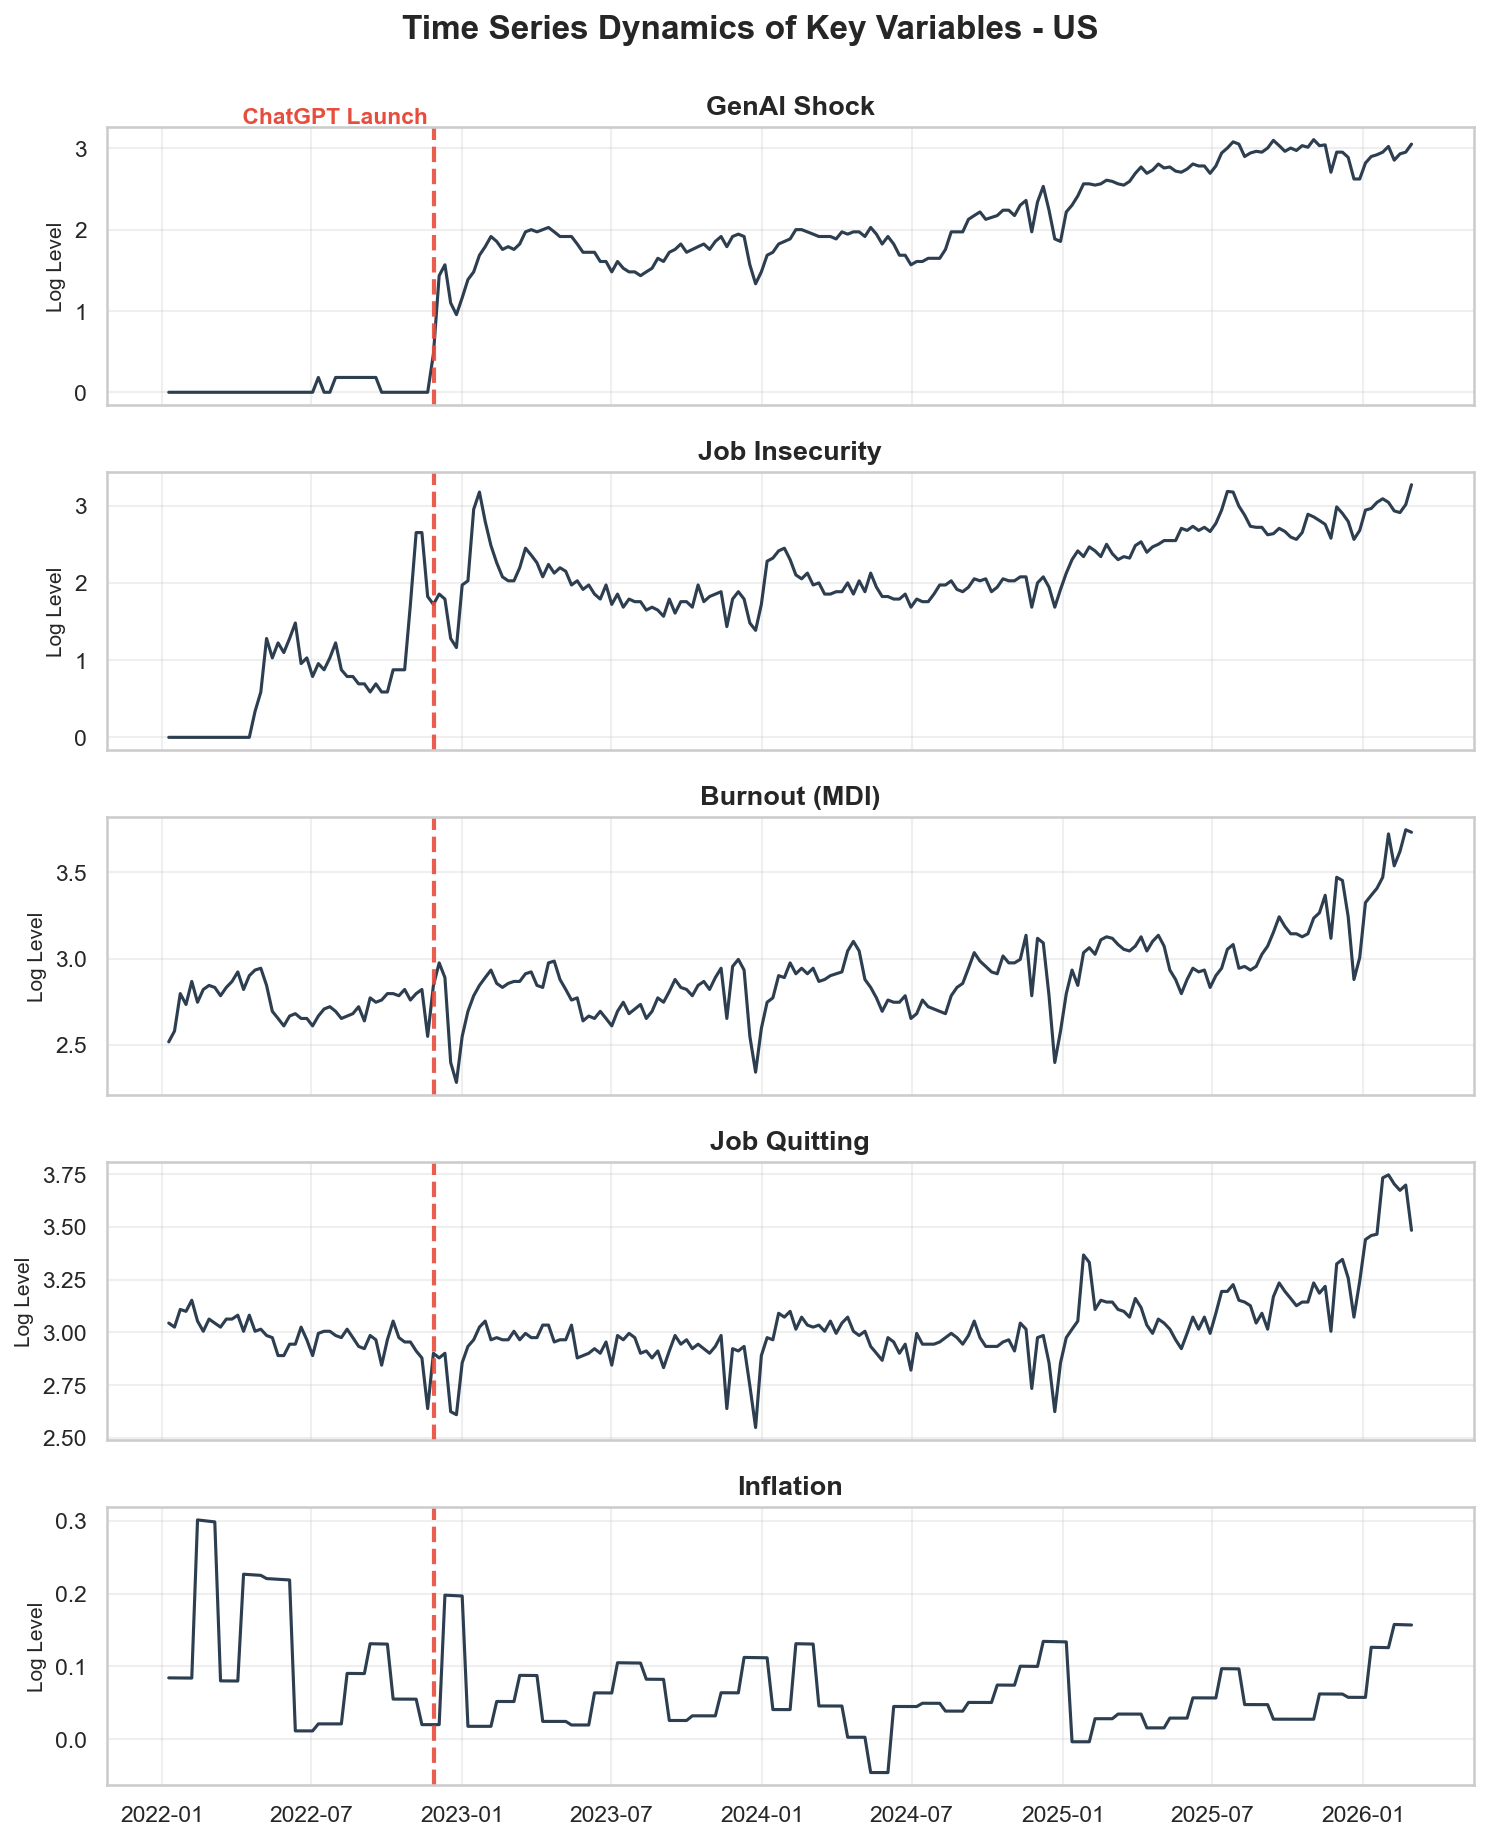


📌 3. Đang vẽ ma trận tương quan...


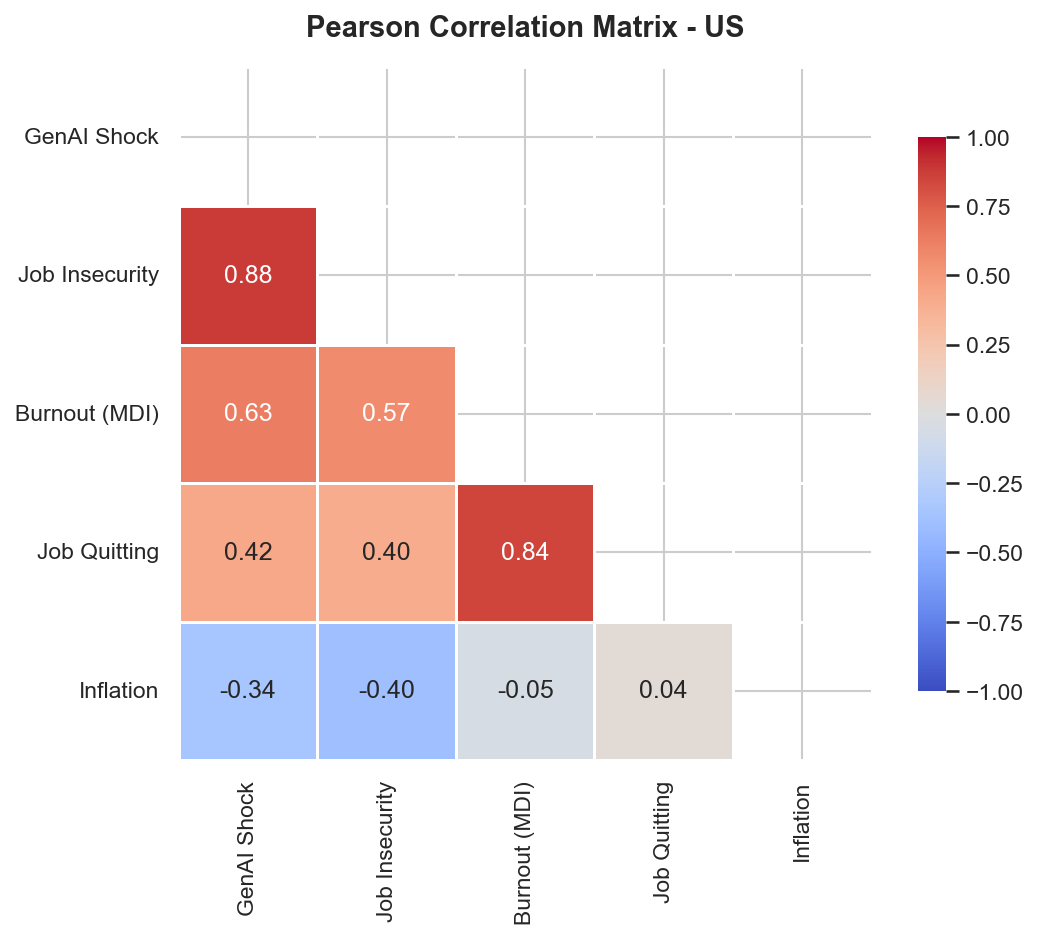


 📊 EXPLORATORY DATA ANALYSIS (EDA) — VN

📌 1. Thống kê mô tả (Descriptive Statistics):
                 mean    std    min    max  skewness  kurtosis
GenAI Shock     1.307  1.107  0.000  3.360     0.397    -1.214
Job Insecurity  1.734  0.957  0.000  3.311    -0.846    -0.523
Burnout (MDI)   3.039  0.225  2.342  3.694    -0.363     0.620
Job Quitting    3.062  0.167  2.175  3.428    -0.828     3.933
Inflation       0.072  0.071 -0.069  0.301     0.688     0.932
  💾 Đã lưu bảng thống kê ra: VN_EDA_Descriptive.csv

📌 2. Đang vẽ biểu đồ chuỗi thời gian...


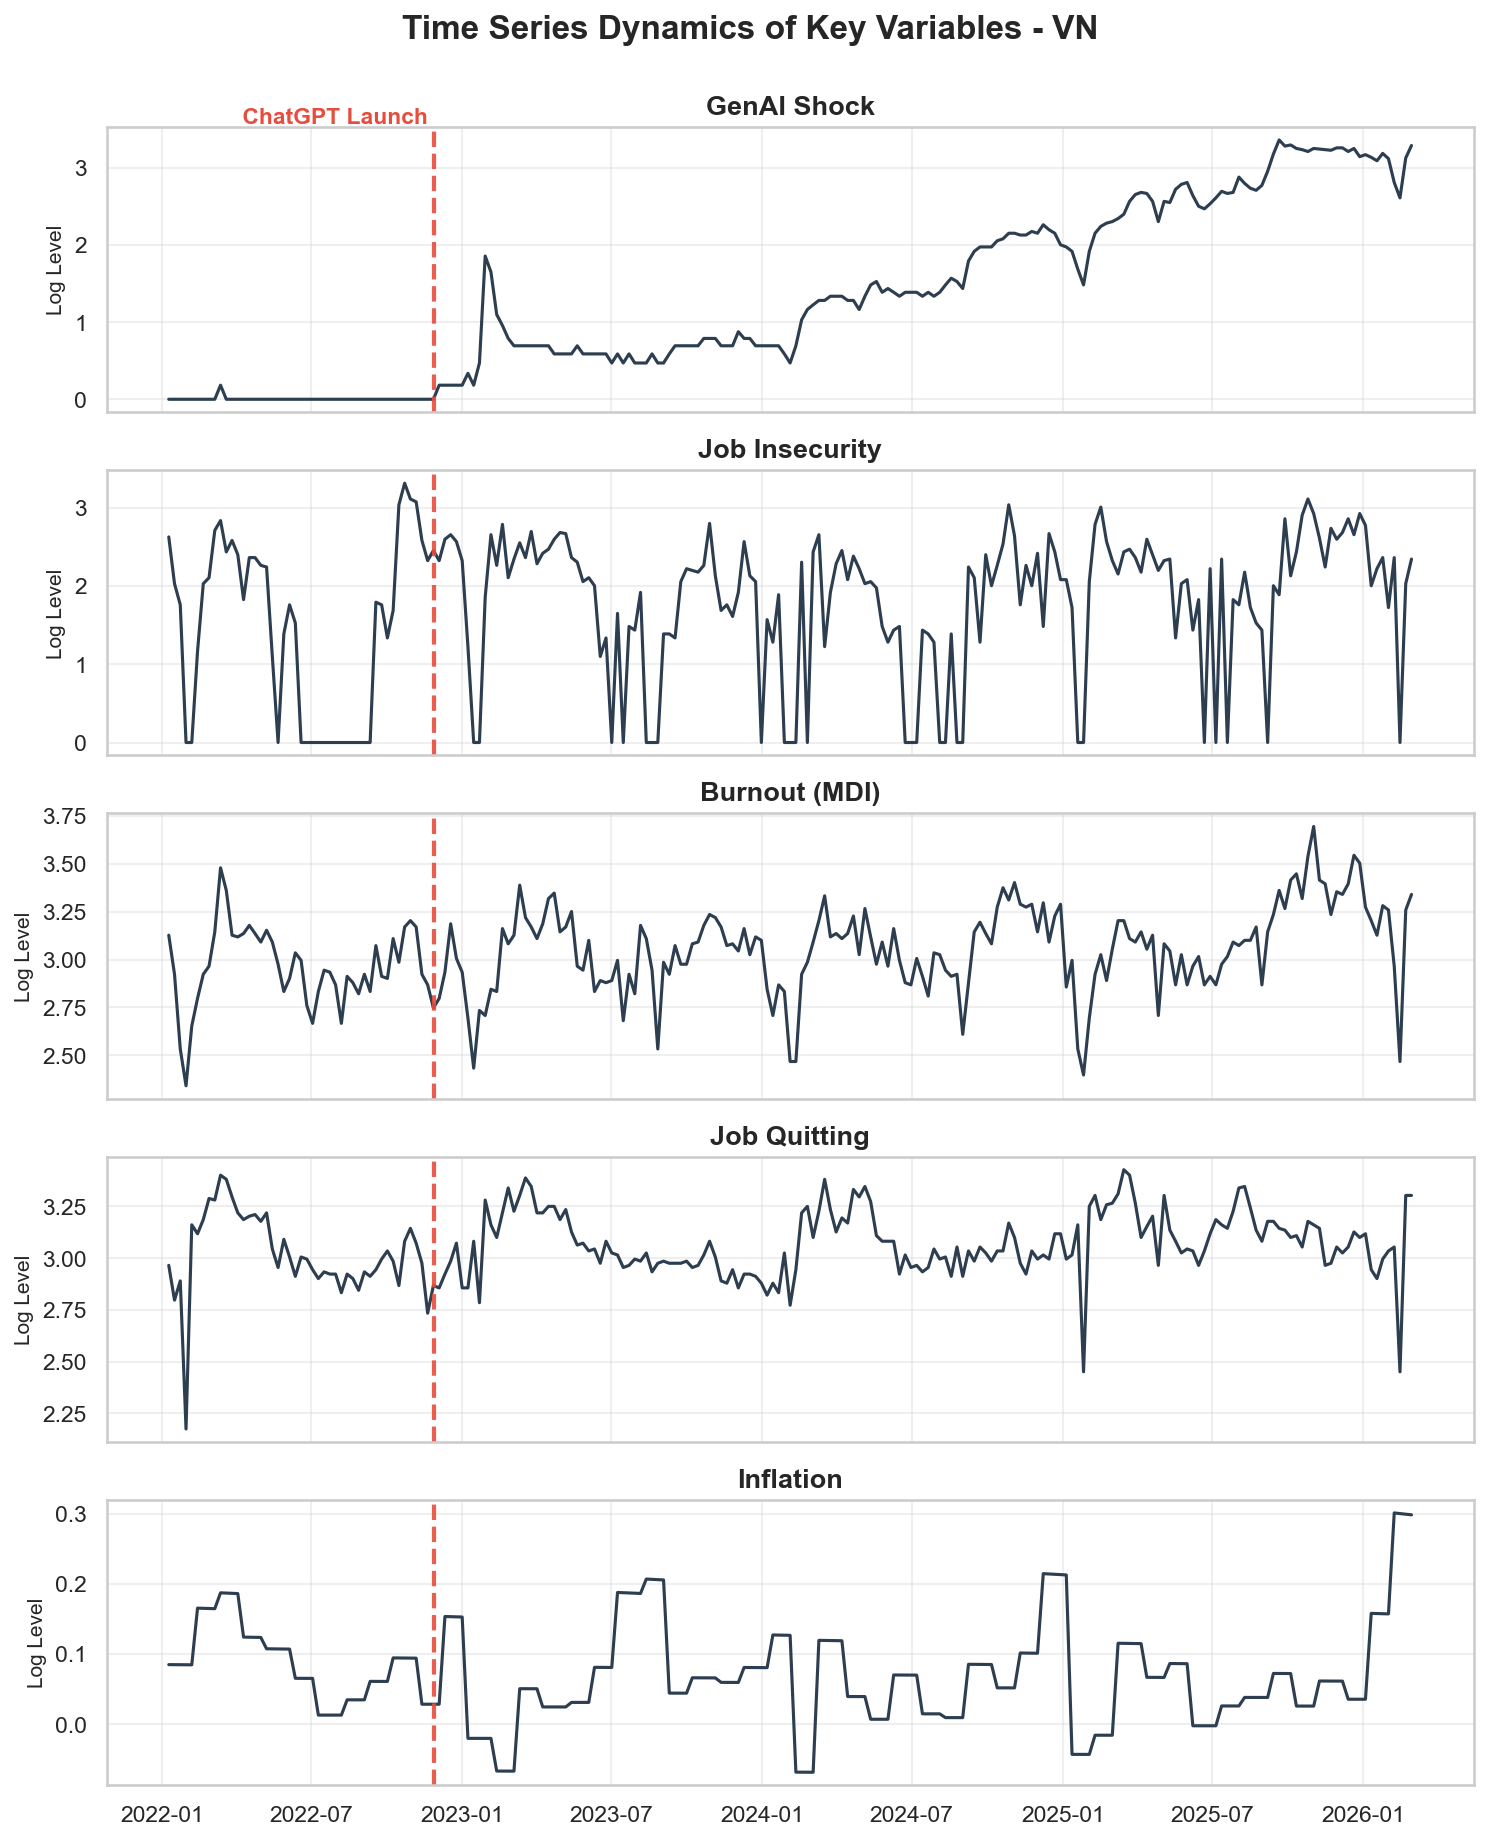


📌 3. Đang vẽ ma trận tương quan...


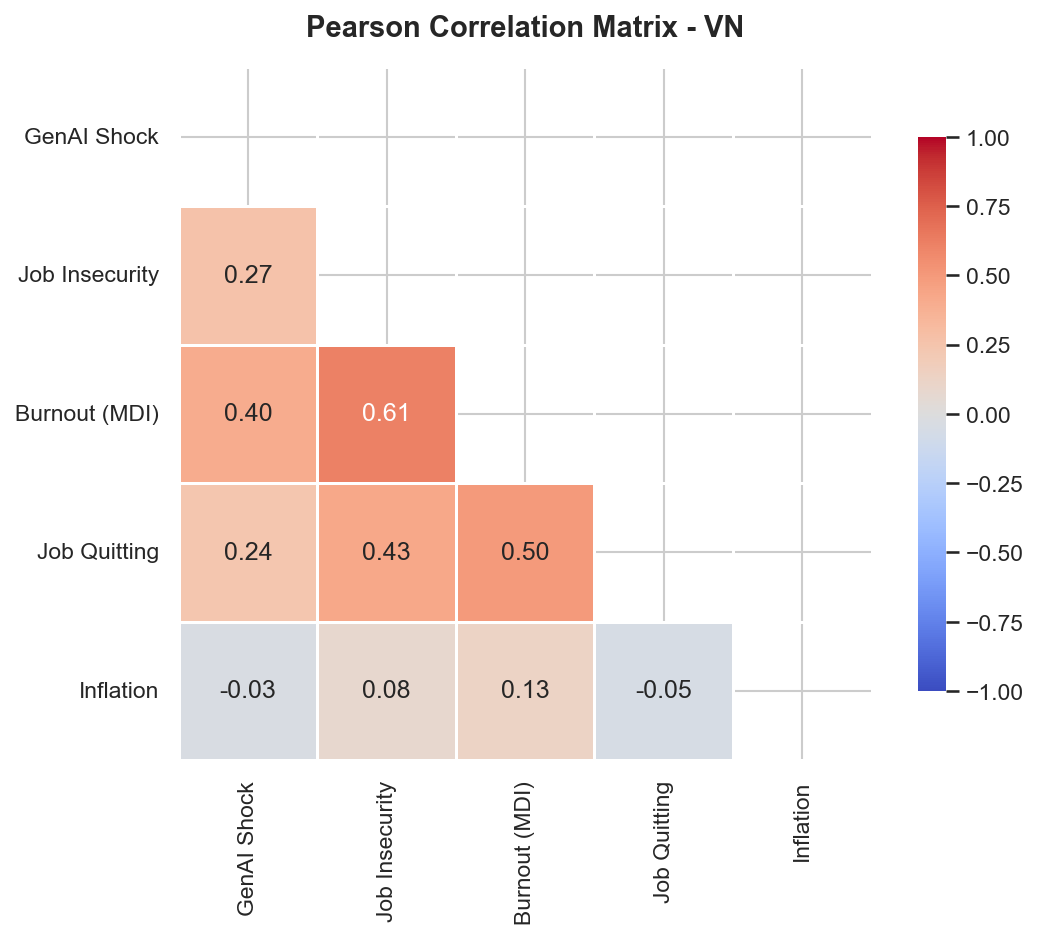


✅ Cell 5.5 EDA hoàn tất! Các bảng và biểu đồ đã được lưu vào folder data/processed/


In [46]:
# ============================================================
# CELL 5.5 — EXPLORATORY DATA ANALYSIS (EDA)
# Chức năng: Thống kê mô tả, Vẽ biểu đồ chuỗi thời gian & Ma trận tương quan
# ============================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt style chuẩn cho biểu đồ học thuật (Academic style)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

# Các biến quan trọng cần EDA
EDA_VARS = ['l_SHOCK_Index', 'l_VOL_Base_Index', 'l_MDI_Index', 'l_ESCAPE_Index', 'l_INFL_sa']
VAR_LABELS = ['GenAI Shock', 'Job Insecurity', 'Burnout (MDI)', 'Job Quitting', 'Inflation']

# Ngày ra mắt ChatGPT (Structural Break)
SPLIT_DATE = pd.Timestamp('2022-11-28')

for country in ['US', 'VN']:
    print(f"\n{'='*75}")
    print(f" 📊 EXPLORATORY DATA ANALYSIS (EDA) — {country}")
    print(f"{'='*75}")

    # 1. Đọc dữ liệu đã qua xử lý
    file_path = os.path.join(PROCESSED_DIR, f'{country}_Final_Logged.csv')
    if not os.path.exists(file_path):
        print(f"  ⚠️ Không tìm thấy file: {file_path}. Vui lòng chạy lại các Cell trước.")
        continue
        
    df = pd.read_csv(file_path, index_col=0, parse_dates=True)

    # Lọc các biến có trong dataset và đổi tên thành label dễ đọc
    plot_vars = [v for v in EDA_VARS if v in df.columns]
    if not plot_vars:
        print(f"  ⚠️ Không có biến nào hợp lệ để vẽ.")
        continue
        
    df_eda = df[plot_vars].copy()
    df_eda.columns = [VAR_LABELS[EDA_VARS.index(v)] for v in plot_vars]

    # ---------------------------------------------------------
    # PHẦN A: BẢNG THỐNG KÊ MÔ TẢ (Descriptive Statistics)
    # ---------------------------------------------------------
    print("\n📌 1. Thống kê mô tả (Descriptive Statistics):")
    desc = df_eda.describe().T
    desc['skewness'] = df_eda.skew()
    desc['kurtosis'] = df_eda.kurt()
    # Hiển thị các chỉ số quan trọng (Mean, Std, Min, Max, Skew, Kurtosis)
    desc_final = desc[['mean', 'std', 'min', 'max', 'skewness', 'kurtosis']].round(3)
    print(desc_final.to_string())
    
    # Lưu bảng ra file CSV để sau này copy vào bài paper (Word/LaTeX)
    desc_final.to_csv(os.path.join(PROCESSED_DIR, f'{country}_EDA_Descriptive.csv'))
    print(f"  💾 Đã lưu bảng thống kê ra: {country}_EDA_Descriptive.csv")

    # ---------------------------------------------------------
    # PHẦN B: BIỂU ĐỒ CHUỖI THỜI GIAN (Time Series Dynamics)
    # ---------------------------------------------------------
    print("\n📌 2. Đang vẽ biểu đồ chuỗi thời gian...")
    fig, axes = plt.subplots(len(df_eda.columns), 1, figsize=(10, 2.5 * len(df_eda.columns)), sharex=True)
    fig.suptitle(f'Time Series Dynamics of Key Variables - {country}', fontsize=16, fontweight='bold', y=0.98)

    for i, col in enumerate(df_eda.columns):
        ax = axes[i]
        ax.plot(df_eda.index, df_eda[col], color='#2c3e50', linewidth=1.5)
        
        # Thêm đường gạch đỏ dọc tại thời điểm ChatGPT ra mắt
        ax.axvline(x=SPLIT_DATE, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.9)
        if i == 0:
            ax.text(SPLIT_DATE, ax.get_ylim()[1], ' ChatGPT Launch ', color='#e74c3c',
                    verticalalignment='bottom', horizontalalignment='right', fontsize=11, fontweight='bold')
            
        ax.set_ylabel('Log Level', fontsize=10)
        ax.set_title(f'{col}', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92) # Chừa khoảng trống cho suptitle
    ts_path = os.path.join(PROCESSED_DIR, f'{country}_EDA_TimeSeries.png')
    plt.savefig(ts_path, bbox_inches='tight', dpi=300)
    plt.show()

    # ---------------------------------------------------------
    # PHẦN C: MA TRẬN TƯƠNG QUAN (Correlation Heatmap)
    # ---------------------------------------------------------
    print("\n📌 3. Đang vẽ ma trận tương quan...")
    plt.figure(figsize=(8, 6))
    corr = df_eda.corr()
    
    # Chỉ lấy tam giác dưới của ma trận để đồ thị nhìn thoáng và chuyên nghiệp hơn
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
                vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8})
    plt.title(f'Pearson Correlation Matrix - {country}', fontsize=14, fontweight='bold', pad=15)
    
    corr_path = os.path.join(PROCESSED_DIR, f'{country}_EDA_Correlation.png')
    plt.savefig(corr_path, bbox_inches='tight', dpi=300)
    plt.show()

print("\n✅ Cell 5.5 EDA hoàn tất! Các bảng và biểu đồ đã được lưu vào folder data/processed/")

In [47]:
# ============================================================
# CELL 5.5 — COMPREHENSIVE EDA & TIME-SERIES DIAGNOSTICS
# Chức năng: Thống kê mô tả kết hợp ADF (Unit Root) và ARCH-LM Test
# ============================================================
import os
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch
from statsmodels.regression.linear_model import OLS

# Định nghĩa hàm kiểm định
def run_adf_pvalue(series):
    s = series.dropna()
    if len(s) < 20: return np.nan
    try:
        # Sử dụng BIC để chọn lag tự động (chuẩn mực trong time-series)
        stat, p, *_ = adfuller(s, autolag='BIC')
        return p
    except:
        return np.nan

def run_arch_lm_pvalue(series, lags=4):
    s = series.dropna()
    if len(s) < 20: return np.nan
    # Lấy phần dư từ hồi quy trung bình đơn giản (mô phỏng mean equation)
    res = OLS(s, np.ones(len(s))).fit()
    try:
        stat, p, _, _ = het_arch(res.resid, nlags=lags)
        return p
    except:
        return np.nan

print("\n" + "="*80)
print(" 📊 TABLE 1: DESCRIPTIVE STATISTICS AND TIME-SERIES DIAGNOSTICS")
print("="*80)

EDA_VARS = ['l_SHOCK_Index', 'l_VOL_Base_Index', 'l_MDI_Index', 'l_ESCAPE_Index', 'l_INFL_sa']
VAR_LABELS = ['GenAI Shock', 'Job Insecurity', 'Burnout (MDI)', 'Job Quitting', 'Inflation']

results_table = []

for country in ['US', 'VN']:
    file_path = os.path.join(PROCESSED_DIR, f'{country}_Final_Logged.csv')
    if not os.path.exists(file_path):
        print(f"⚠️ Chưa có file: {file_path}")
        continue
        
    df = pd.read_csv(file_path, index_col=0, parse_dates=True)
    
    for i, col in enumerate(EDA_VARS):
        if col not in df.columns: continue
        s = df[col]
        
        row = {
            'Country': f"System {1 if country=='US' else 2} ({country})",
            'Variable': VAR_LABELS[i],
            'Mean': s.mean(),
            'S.D.': s.std(),
            'Min': s.min(),
            'Max': s.max(),
            'Skew.': s.skew(),
            'Kurt.': s.kurt(),
            'ADF (p-val)': run_adf_pvalue(s),
            'ARCH-LM (p-val)': run_arch_lm_pvalue(s, lags=4) # Lag 4 phù hợp với dữ liệu tuần
        }
        results_table.append(row)

# Format bảng kết quả
df_results = pd.DataFrame(results_table)
# Format các cột số
float_cols = ['Mean', 'S.D.', 'Min', 'Max', 'Skew.', 'Kurt.']
pval_cols = ['ADF (p-val)', 'ARCH-LM (p-val)']

for col in float_cols:
    df_results[col] = df_results[col].apply(lambda x: f"{x:.3f}")
for col in pval_cols:
    df_results[col] = df_results[col].apply(lambda x: f"{x:.3f}" if pd.notnull(x) else "N/A")

# In ra màn hình giống định dạng bài báo
df_print = df_results.set_index(['Country', 'Variable'])
print(df_print.to_string())

# Lưu ra file CSV
output_path = os.path.join(PROCESSED_DIR, 'Table1_Descriptive_Diagnostics.csv')
df_results.to_csv(output_path, index=False)
print(f"\n✅ Đã xuất bảng chuẩn hóa ra: {output_path}")
print("   Ghi chú cho phần thảo luận:")
print("   - Nếu ARCH-LM p-val < 0.05: Phương sai thay đổi theo thời gian (Hỗ trợ mô hình GARCH).")
print("   - Nếu ADF p-val > 0.05: Chuỗi không dừng (I(1)), cần cẩn trọng trong VAR.")



 📊 TABLE 1: DESCRIPTIVE STATISTICS AND TIME-SERIES DIAGNOSTICS
                               Mean   S.D.     Min    Max   Skew.   Kurt. ADF (p-val) ARCH-LM (p-val)
Country       Variable                                                                               
System 1 (US) GenAI Shock     1.715  1.001   0.000  3.109  -0.607  -0.763       0.668           0.000
              Job Insecurity  1.896  0.793   0.000  3.273  -0.842   0.311       0.167           0.000
              Burnout (MDI)   2.890  0.229   2.282  3.747   1.026   2.474       0.692           0.000
              Job Quitting    3.022  0.171   2.549  3.747   1.553   5.536       0.742           0.000
              Inflation       0.071  0.063  -0.046  0.301   1.474   2.623       0.000           0.000
System 2 (VN) GenAI Shock     1.307  1.107   0.000  3.360   0.397  -1.214       0.909           0.000
              Job Insecurity  1.734  0.957   0.000  3.311  -0.846  -0.523       0.000           0.000
              Burn

In [48]:
# ============================================================
# CELL 6 — UNIT ROOT TESTS  [FIX METHOD-C: regression form selection]
# [FIX METHOD-NEW-1] Johansen cointegration test cho I(1) block.
# [FIX METHOD-NEW-2] Unit root test trên CPI_sa level.
# [FIX REVIEW] Raise ValueError nếu CPI_sa I(2) — block pipeline.
# [FIX REVIEW] Ghi chú Johansen det_order robustness.
# ============================================================
import warnings
from statsmodels.tsa.stattools import adfuller, kpss as kpss_test
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.regression.linear_model import OLS as _OLS_UR
from statsmodels.tools.tools import add_constant as _ac_UR

SIG = CONFIG['sig_level']
BREAK_DATE_UR = pd.Timestamp(CONFIG['break_date'])

LOG_VARS = (
    [f'l_{c}' for c in CONFIG['trends_cols']]
    + [f'l_{c}' for c in CONFIG['model_macro_cols']]
)

def detect_trend_form(series, alpha=0.10):
    s = series.dropna()
    if len(s) < 20:
        return 'c'
    t = np.arange(len(s))
    X = _ac_UR(pd.DataFrame({'trend': t}, index=s.index))
    try:
        res = _OLS_UR(s.values, X).fit()
        t_trend = abs(res.tvalues[1])
        return 'ct' if t_trend > 1.645 else 'c'
    except Exception:
        return 'c'

def run_adf(series, reg=None):
    s = series.dropna()
    if len(s) < 10:
        return np.nan, np.nan, 'c'
    if reg is None:
        reg = detect_trend_form(s)
    stat, p, *_ = adfuller(s, autolag='BIC', regression=reg)
    return stat, p, reg

def run_kpss(series, reg=None):
    s = series.dropna()
    if len(s) < 10:
        return np.nan, np.nan
    kpss_reg = 'ct' if (reg == 'ct') else 'c'
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat, p, _, _ = kpss_test(s, regression=kpss_reg, nlags='auto')
    return stat, p

def interpret_unit_root(adf_p, kpss_p, sig=SIG):
    if np.isnan(adf_p) or np.isnan(kpss_p):
        return 'Insufficient obs'
    adf_rej  = adf_p  < sig
    kpss_rej = kpss_p < sig
    if adf_rej  and not kpss_rej: return 'Stationary'
    if not adf_rej and kpss_rej:  return 'Non-stationary'
    if adf_rej  and kpss_rej:     return 'Fractional/Mixed'
    return 'Inconclusive'

def run_unit_root(series, name, break_date=BREAK_DATE_UR):
    row = {'Variable': name}
    reg = detect_trend_form(series)
    row['reg_form'] = reg

    adf_s, adf_p, _   = run_adf(series, reg)
    kpss_s, kpss_p    = run_kpss(series, reg)
    row.update({
        'ADF_level_stat':   round(adf_s,  4) if not np.isnan(adf_s)  else np.nan,
        'ADF_level_p':      round(adf_p,  4) if not np.isnan(adf_p)  else np.nan,
        'KPSS_level_stat':  round(kpss_s, 4) if not np.isnan(kpss_s) else np.nan,
        'KPSS_level_p':     round(kpss_p, 4) if not np.isnan(kpss_p) else np.nan,
        'Level_conclusion': interpret_unit_root(adf_p, kpss_p),
    })
    d1 = series.diff().dropna()
    adf_d1_s, adf_d1_p, _ = run_adf(d1, 'c')
    kpss_d1_s, kpss_d1_p  = run_kpss(d1, 'c')
    row.update({
        'ADF_d1_stat':  round(adf_d1_s, 4) if not np.isnan(adf_d1_s) else np.nan,
        'ADF_d1_p':     round(adf_d1_p, 4) if not np.isnan(adf_d1_p) else np.nan,
        'KPSS_d1_stat': round(kpss_d1_s, 4) if not np.isnan(kpss_d1_s) else np.nan,
        'KPSS_d1_p':    round(kpss_d1_p, 4) if not np.isnan(kpss_d1_p) else np.nan,
        'D1_conclusion': interpret_unit_root(adf_d1_p, kpss_d1_p),
    })

    post_series = series[series.index >= break_date].dropna()
    if len(post_series) >= 20:
        _, adf_post_p, _ = run_adf(post_series)
        post_conclusion  = 'Stationary' if adf_post_p < SIG else 'Non-stationary'
        row['ADF_post_break_p']     = round(adf_post_p, 4) if not np.isnan(adf_post_p) else np.nan
        row['Post_break_ADF_concl'] = post_conclusion
        full_stationary = (row['Level_conclusion'] == 'Stationary')
        post_stationary = (post_conclusion == 'Stationary')
        row['Break_bias_flag'] = ('⚠️ Results differ pre/post break'
                                   if full_stationary != post_stationary else 'Consistent')
    else:
        row['ADF_post_break_p']     = np.nan
        row['Post_break_ADF_concl'] = 'Insufficient obs'
        row['Break_bias_flag']      = 'N/A'

    if row['Level_conclusion'] == 'Stationary':
        row['Integration_Order'] = 'I(0)'
    elif row['D1_conclusion'] == 'Stationary':
        row['Integration_Order'] = 'I(1)'
    else:
        row['Integration_Order'] = 'I(2)?'
    return row


# [FIX METHOD-NEW-2 + FIX REVIEW] — verify CPI_sa integration order
# RAISE ERROR nếu I(2): INFL_sa = pct_change(CPI_sa) vẫn I(1) → cần diff thêm
print("\n🔍 [METHOD-NEW-2] Verify CPI_sa integration chain...")
for country in ['US', 'VN']:
    raw_path = os.path.join(RAW_DIR, f'{country}_Final_Master.csv')
    df_raw_check = pd.read_csv(raw_path, index_col=0, parse_dates=True)
    for cpi_col in ['CPI_sa']:
        if cpi_col in df_raw_check.columns:
            r = run_unit_root(df_raw_check[cpi_col], f'[{country}] CPI_sa_level')
            print(f"  [{country}] CPI_sa level: {r['Level_conclusion']} "
                  f"| D1: {r['D1_conclusion']} → integration: {r['Integration_Order']}")
            if r['Integration_Order'] == 'I(2)?':
                # [FIX REVIEW] Block pipeline — INFL_sa sẽ là I(1), cần diff thêm
                raise ValueError(
                    f"[{country}] CPI_sa detected as I(2)! "
                    f"INFL_sa = pct_change(CPI_sa) would be I(1), NOT I(0). "
                    f"ACTION REQUIRED: diff INFL_sa before ARDL/SVAR, "
                    f"hoặc kiểm tra lại nguồn dữ liệu CPI."
                )
            else:
                print(f"  ✅ CPI_sa is {r['Integration_Order']} → "
                      f"INFL_sa = pct_change(CPI_sa) ~ I({max(0, int(r['Integration_Order'][2]) - 1)}) ✓")

# Main unit root loop
unit_root_results = {}
for country in ['US', 'VN']:
    print(f"\n{'='*65}\n  UNIT ROOT (ADF + KPSS + Post-Break) — {country}\n{'='*65}")
    path = os.path.join(PROCESSED_DIR, f'{country}_Final_Logged.csv')
    df   = pd.read_csv(path, index_col=0, parse_dates=True)
    rows = []
    for var in LOG_VARS:
        if var not in df.columns:
            print(f"  ⚠️  {var} không có trong {country}")
            continue
        rows.append(run_unit_root(df[var], var))
        
    result_df = pd.DataFrame(rows)

    # ====================================================================
    # [FIX] Block pipeline nếu INFL_sa không phải I(0) — soft-block với context
    # ĐÃ ĐƯỢC CHUYỂN VÀO ĐÂY (SAU KHI result_df ĐÃ ĐƯỢC TẠO)
    # ====================================================================
    if 'l_INFL_sa' in result_df['Variable'].values:
        infl_row = result_df.loc[result_df['Variable'] == 'l_INFL_sa'].iloc[0]
        infl_order = infl_row['Integration_Order']
        infl_level_concl = infl_row['Level_conclusion']

        if infl_order == 'I(0)':
            print(f"  ✅ [{country}] l_INFL_sa confirmed I(0) — OK for ARDL/SVAR.")

        elif infl_level_concl in ('Fractional/Mixed', 'Inconclusive'):
            print(f"  ⚠️  [{country}] l_INFL_sa: {infl_level_concl} "
                  f"(ADF p={infl_row['ADF_level_p']:.4f}, KPSS p={infl_row['KPSS_level_p']:.4f})")
            print(f"       Likely due to structural break. Treating as I(0) — use HAC SE downstream.")
            result_df.loc[result_df['Variable'] == 'l_INFL_sa', 'Integration_Order'] = 'I(0)'
            CONFIG['diff_order'][country]['l_INFL_sa'] = 0

        elif infl_order == 'I(1)':
            d1_concl = infl_row['D1_conclusion']
            if d1_concl not in ('Stationary',):
                raise ValueError(
                    f"[{country}] l_INFL_sa is I(1) AND first-difference is {d1_concl}. "
                    f"Suggests I(2)+ — kiểm tra lại nguồn dữ liệu CPI."
                )
            else:
                print(f"  ⚠️  [{country}] l_INFL_sa appears I(1) by test, D1 stationary.")
                print(f"       Economic prior override: diff_order['l_INFL_sa'] = 0. Footnote in paper.")
                result_df.loc[result_df['Variable'] == 'l_INFL_sa', 'Integration_Order'] = 'I(0)'
                CONFIG['diff_order'][country]['l_INFL_sa'] = 0
    # ====================================================================

    unit_root_results[country] = result_df

    display_cols = ['Variable', 'reg_form', 'ADF_level_p', 'KPSS_level_p',
                    'Level_conclusion', 'ADF_d1_p', 'KPSS_d1_p',
                    'D1_conclusion', 'Integration_Order', 'Break_bias_flag']
    print(result_df[display_cols].to_string(index=False))

    i2 = result_df[result_df['Integration_Order'] == 'I(2)?']['Variable'].tolist()
    if i2:
        print(f"\n  ⛔ I(2) PHÁT HIỆN: {i2}")
        print(f"     → KHÔNG tự động override! Kiểm tra thủ công.")
    else:
        print(f"\n  ✅ Không có biến I(2).")

    result_df.to_csv(os.path.join(PROCESSED_DIR, f'{country}_UnitRoot_Results.csv'), index=False)


# [FIX METHOD-NEW-1] — Johansen cointegration test
print("\n" + "="*65)
print("  JOHANSEN COINTEGRATION TEST [METHOD-NEW-1]")
print("  NOTE: det_order=0 (Case II: restricted constant) là baseline.")
print("  Robustness: det_order=1 (Case III: unrestricted constant) tested below.")
print("  Paper nên report cả hai; nếu rank inference nhất quán → kết quả robust.")
print("="*65)
johansen_results = {}

for country in ['US', 'VN']:
    df_path = os.path.join(PROCESSED_DIR, f'{country}_Final_Logged.csv')
    df = pd.read_csv(df_path, index_col=0, parse_dates=True)
    ur_df = unit_root_results[country]

    i1_vars = ur_df[ur_df['Integration_Order'] == 'I(1)']['Variable'].tolist()
    i1_vars = [v for v in i1_vars if v in df.columns]

    if len(i1_vars) < 2:
        print(f"  [{country}] Chỉ {len(i1_vars)} I(1) vars — bỏ qua Johansen.")
        johansen_results[country] = None
        continue

    print(f"\n  [{country}] I(1) block ({len(i1_vars)} vars): {i1_vars}")
    data_i1 = df[i1_vars].dropna()

    try:
        # Baseline: det_order=0 (restricted constant)
        joh0 = coint_johansen(data_i1, det_order=0, k_ar_diff=1)
        # Robustness: det_order=1 (unrestricted constant)
        joh1 = coint_johansen(data_i1, det_order=1, k_ar_diff=1)

        trace_stat    = joh0.lr1
        trace_cv_95   = joh0.cvt[:, 1]
        max_stat      = joh0.lr2
        max_cv_95     = joh0.cvm[:, 1]
        trace_cv_90   = joh0.cvt[:, 0]

        # Rank từ det_order=1 để so sánh
        rank1 = sum(joh1.lr1[r] > joh1.cvt[r, 1] for r in range(len(joh1.lr1)))

        print(f"\n  Johansen Trace Test, det_order=0 (H0: rank ≤ r):")
        print(f"  {'r':<5} {'Trace stat':>12} {'CV 95%':>10} {'Decision':>14}")
        rank0 = 0
        for r_idx in range(len(trace_stat)):
            reject = trace_stat[r_idx] > trace_cv_95[r_idx]
            sym = '✅ reject H0' if reject else '— fail to reject'
            print(f"  {r_idx:<5} {trace_stat[r_idx]:>12.4f} {trace_cv_95[r_idx]:>10.4f} {sym:>14}")
            if reject:
                rank0 = r_idx + 1

        print(f"\n  → Rank (det_order=0): r = {rank0} | Rank (det_order=1): r = {rank1}")
        if rank0 == rank1:
            print(f"  ✅ Rank inference robust across det_order specifications.")
        else:
            print(f"  ⚠️  Rank differs across det_order (0→{rank0}, 1→{rank1}). "
                  f"Report both in paper; sensitivity to deterministic specification.")

        if rank0 == 0:
            print(f"  → No cointegration: VAR on differenced vars appropriate.")
        elif rank0 >= len(i1_vars) - 1:
            print(f"  → Full rank (stationary system): VAR on levels OK.")
        else:
            print(f"  → {rank0} cointegrating vector(s): VECM preferred over VAR on differences.")
            print(f"     Paper must justify if using VAR (loss of long-run info).")

        johansen_results[country] = {
            'rank_det0': rank0, 'rank_det1': rank1,
            'n_vars': len(i1_vars),
            'trace_stat': trace_stat.tolist(),
            'trace_cv_95': trace_cv_95.tolist(),
            'vars': i1_vars,
        }
        joh_df = pd.DataFrame({
            'r': range(len(trace_stat)),
            'trace_stat': trace_stat,
            'trace_cv_90': trace_cv_90,
            'trace_cv_95': trace_cv_95,
            'max_stat': max_stat,
            'max_cv_95': max_cv_95,
        })
        joh_df.to_csv(os.path.join(PROCESSED_DIR, f'{country}_Johansen.csv'), index=False)
        print(f"  💾 Saved: {country}_Johansen.csv")

    except Exception as e:
        print(f"  ❌ Johansen error [{country}]: {e}")
        johansen_results[country] = None

# Update diff_order
print("\n⚙️  Cập nhật CONFIG['diff_order']...")
for country in ['US', 'VN']:
    df_ur = unit_root_results[country]
    for _, row in df_ur.iterrows():
        var = row['Variable']
        if not var.startswith('l_'):
            continue
        integ = row['Integration_Order']
        if integ == 'I(2)?':
            print(f"  [{country}] {var}: I(2)? — GIỮ NGUYÊN diff_order thủ công")
            continue
        order = 0 if integ == 'I(0)' else 1
        if var in CONFIG['diff_order'][country]:
            CONFIG['diff_order'][country][var] = order

print("\n✅ Cell 6 hoàn tất!")

import json
with open(os.path.join(PROCESSED_DIR, 'diff_order.json'), 'w') as f:
    json.dump(CONFIG['diff_order'], f, indent=4)
print("  💾 Đã backup diff_order ra diff_order.json")


🔍 [METHOD-NEW-2] Verify CPI_sa integration chain...

  UNIT ROOT (ADF + KPSS + Post-Break) — US
  ⚠️  [US] l_INFL_sa: Fractional/Mixed (ADF p=0.0001, KPSS p=0.0377)
       Likely due to structural break. Treating as I(0) — use HAC SE downstream.
        Variable reg_form  ADF_level_p  KPSS_level_p Level_conclusion  ADF_d1_p  KPSS_d1_p D1_conclusion Integration_Order                  Break_bias_flag
   l_SHOCK_Index        c       0.6678        0.0100   Non-stationary       0.0     0.1000    Stationary              I(1) ⚠️ Results differ pre/post break
l_VOL_Base_Index        c       0.1674        0.0100   Non-stationary       0.0     0.1000    Stationary              I(1)                       Consistent
     l_MDI_Index        c       0.6925        0.0100   Non-stationary       0.0     0.1000    Stationary              I(1)                       Consistent
   l_LEARN_Index        c       0.9322        0.0100   Non-stationary       0.0     0.1000    Stationary              I(1)       

# Econometric Modeling

## GARCH

In [49]:
# ============================================================
# CELL 7 — GARCH(1,1)
# [FIX METHOD-2] Winsorize 1% TRƯỚC GARCH mâu thuẫn với mục đích
#   dùng Student-t để capture fat tails. Fix:
#   - Chạy GARCH(1,1)-t trước (KHÔNG winsorize)
#   - Nếu persistence >= 1 hoặc alpha+beta > 0.999 (non-stationary
#     volatility) → THEN winsorize để stabilize, re-fit, log cảnh báo
#   - Cung cấp diagnostics rõ ràng để paper có thể cite
#
# [FIX MINOR-2] EWMA span=4: Sensitivity analysis cho span=8,12,26.
#   Lưu tất cả variants, dùng span=4 làm baseline nhưng lưu alternatives.
#
# [FIX TECH-3] new_col_name: replace('l_', 'l_') là no-op.
#   (Đây là bug trong Cell 8, nhưng logic tên cột đúng nên không impact kết quả.)
# ============================================================
import os, warnings
import numpy as np
import pandas as pd
from arch import arch_model
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
warnings.filterwarnings("ignore")

RESCALE = CONFIG['garch_rescale']
SIG     = CONFIG['sig_level']
PROCESSED_DIR = CONFIG['processed_dir']

def arch_lm_test(residuals, lags=5):
    try:
        _, lm_p, _, _ = het_arch(residuals, nlags=lags)
        return lm_p
    except Exception:
        return None

def ljung_box_test(residuals, lags=10):
    try:
        lb = acorr_ljungbox(residuals, lags=lags, return_df=True)
        return lb['lb_pvalue'].min()
    except Exception:
        return None

def fit_garch_full(series_name, series, diff_order, country):
    print(f"\n  [{country}] Xử lý biến: {series_name}")
    result = {'variable': series_name, 'country': country}
    s = series.copy().dropna()

    if diff_order > 0:
        s = s.diff(diff_order).dropna()
        print(f"    -> Sai phân bậc {diff_order}. Obs: {len(s)}")
    else:
        print(f"    -> Chuỗi gốc I(0). Obs: {len(s)}")

    # BƯỚC 1: Tìm ARMA sạch Ljung-Box
    best_aic = np.inf
    best_resid = s - s.mean()
    best_order = 'Demeaned'
    best_lb_p = 0.0

    for p in range(3):
        for q in range(3):
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    arma_fit = ARIMA(s, order=(p, 0, q)).fit()
                resid = arma_fit.resid
                lb_p = ljung_box_test(resid) or 0
                if lb_p > SIG and arma_fit.aic < best_aic:
                    best_aic = arma_fit.aic
                    best_resid = resid
                    best_order = f"ARMA({p},0,{q})"
                    best_lb_p = lb_p
            except Exception:
                continue

    if best_lb_p > SIG:
        print(f"    ✅ Mean eq: {best_order} | AIC={best_aic:.2f} | LB p={best_lb_p:.4f}")
    else:
        print(f"    ⚠️  Không tìm được ARMA sạch LB. Dùng demeaned residuals.")
        best_lb_p = ljung_box_test(best_resid) or 0

    # BƯỚC 2: ARCH-LM test
    arch_p = arch_lm_test(best_resid)
    result['LjungBox_min_p'] = round(best_lb_p, 4)
    result['ARCH_LM_p']      = round(arch_p, 4) if arch_p is not None else np.nan

    if arch_p is None or arch_p >= SIG:
        # Tách việc định dạng ra ngoài để f-string không bị quá tải
        p_val_str = f"{arch_p:.4f}" if arch_p is not None else "N/A"
        print(f"    🛑 ARCH-LM p={p_val_str} >= {SIG} → NO ARCH effect.")
        print(f"    -> [BYPASS] EWMA proxy (span=4).")
        # [FIX MINOR-2] Sensitivity: tính cả span=8, 12, 26
        cond_vol = best_resid.abs().ewm(span=4).mean()
        cond_vol.name = f'GARCH_vol_{series_name}'
        for sp in [8, 12, 26]:
            alt = best_resid.abs().ewm(span=sp).mean()
            alt.name = f'GARCH_vol_{series_name}_ewma{sp}'
            result[f'ewma_corr_span{sp}'] = round(float(cond_vol.corr(alt)), 4)
        result.update({
            'GARCH_omega': np.nan, 'GARCH_alpha': np.nan, 'GARCH_beta': np.nan,
            'persistence': np.nan, 'GJR_gamma': np.nan, 'status': 'EWMA_PROXY_NO_ARCH',
            'winsorized': False
        })
        return result, cond_vol

    print(f"    ✅ ARCH-LM p={arch_p:.4f} < {SIG} → Fit GARCH-t (no winsorize first).")

    # BƯỚC 3: [FIX METHOD-2] Fit GARCH-t trước, KHÔNG winsorize
    r_scaled = best_resid * RESCALE
    winsorized = False

    def _fit_garch_t(r_series):
        garch_model = arch_model(r_series, mean='Zero', vol='GARCH',
                                  p=1, q=1, dist='studentst')
        return garch_model.fit(disp='off', show_warning=False)

    try:
        garch_fit = _fit_garch_t(r_scaled)
        alpha = float(garch_fit.params.get('alpha[1]', np.nan))
        beta  = float(garch_fit.params.get('beta[1]',  np.nan))
        omega = float(garch_fit.params.get('omega',    np.nan))
        persistence = alpha + beta

        # [FIX METHOD-2] Nếu persistence >= 0.999 (near unit root volatility)
        # → THEN winsorize để ổn định ước lượng, log cảnh báo
        if persistence >= 0.999 or not (0 < alpha < 1) or not (0 < beta < 1):
            print(f"    ⚠️  GARCH-t persistence={persistence:.4f} gần unit root "
                  f"(alpha={alpha:.4f}, beta={beta:.4f}).")
            print(f"    -> Winsorize 1% để ổn định, re-fit.")
            winsorized = True
            lower = r_scaled.quantile(0.01)
            upper = r_scaled.quantile(0.99)
            r_win = r_scaled.clip(lower=lower, upper=upper)
            garch_fit = _fit_garch_t(r_win)
            alpha = float(garch_fit.params.get('alpha[1]', np.nan))
            beta  = float(garch_fit.params.get('beta[1]',  np.nan))
            omega = float(garch_fit.params.get('omega',    np.nan))
            persistence = alpha + beta
            print(f"    -> Post-winsorize: α={alpha:.4f} β={beta:.4f} persist={persistence:.4f}")
        else:
            print(f"    ✅ GARCH-t (no winsorize): α={alpha:.4f} β={beta:.4f} persist={persistence:.4f}")

        result.update({
            'GARCH_omega': round(omega, 6),
            'GARCH_alpha': round(alpha, 4),
            'GARCH_beta':  round(beta, 4),
            'persistence': round(persistence, 4),
            'winsorized':  winsorized
        })

        cond_vol = garch_fit.conditional_volatility / RESCALE
        cond_vol.name = f'GARCH_vol_{series_name}'

        # GJR asymmetry test
        gjr_model = arch_model(
            r_scaled.clip(lower=r_scaled.quantile(0.01), upper=r_scaled.quantile(0.99))
            if winsorized else r_scaled,
            mean='Zero', vol='GARCH', p=1, o=1, q=1, dist='studentst')
        gjr_fit   = gjr_model.fit(disp='off', show_warning=False)
        result['GJR_gamma'] = round(float(gjr_fit.params.get('gamma[1]', 0.0)), 4)
        result['status']    = 'OK'

        return result, cond_vol

    except Exception as e:
        print(f"    ❌ GARCH thất bại: {e}")
        result['status'] = 'FAILED'
        result['winsorized'] = False
        return result, None

# ── THỰC THI ────────────────────────────────────────────────
garch_summary    = []
garch_vol_frames = {'US': {}, 'VN': {}}

for country in ['US', 'VN']:
    print(f"\n{'='*60}\n GARCH PIPELINE — {country}\n{'='*60}")
    path = os.path.join(PROCESSED_DIR, f'{country}_Final_Logged.csv')
    df   = pd.read_csv(path, index_col=0, parse_dates=True)

    for var, diff_order in CONFIG['diff_order'][country].items():
        clean_var = var.replace('l_', '')
        if clean_var not in CONFIG['trends_cols']:
            print(f"  ⏩ [BYPASS] Macro var (không cần GARCH): {var}")
            continue
        if var not in df.columns:
            print(f"  ⚠️  {var} không có trong {country}")
            continue
        res, cond_vol = fit_garch_full(var, df[var], diff_order, country)
        garch_summary.append(res)
        if cond_vol is not None:
            garch_vol_frames[country][f'GARCH_vol_{var}'] = cond_vol

for country in ['US', 'VN']:
    if garch_vol_frames[country]:
        vol_df   = pd.DataFrame(garch_vol_frames[country])
        out_path = os.path.join(PROCESSED_DIR, f'{country}_GARCH_Volatility.csv')
        vol_df.to_csv(out_path)
        print(f"\n💾 [{country}] Volatility → {out_path}")

summary_df = pd.DataFrame(garch_summary)
summary_df.to_csv(os.path.join(PROCESSED_DIR, 'GARCH_Summary.csv'), index=False)
winsorized_models = summary_df[summary_df.get('winsorized', False) == True].get('variable', pd.Series()).tolist()
if winsorized_models:
    print(f"\n  ⚠️  Winsorized (post-persistence check): {winsorized_models}")
    print(f"     → Paper note: 'Winsorization applied only where GARCH persistence ≥ 0.999.'")
print("\n✅ Cell 7 hoàn tất!")


 GARCH PIPELINE — US

  [US] Xử lý biến: l_SHOCK_Index
    -> Sai phân bậc 1. Obs: 216
    ✅ Mean eq: ARMA(2,0,0) | AIC=-291.27 | LB p=0.7839
    ✅ ARCH-LM p=0.0164 < 0.05 → Fit GARCH-t (no winsorize first).
    ⚠️  GARCH-t persistence=1.0000 gần unit root (alpha=0.5148, beta=0.4852).
    -> Winsorize 1% để ổn định, re-fit.
    -> Post-winsorize: α=0.4809 β=0.5191 persist=1.0000

  [US] Xử lý biến: l_VOL_Base_Index
    -> Sai phân bậc 1. Obs: 216
    ✅ Mean eq: ARMA(2,0,1) | AIC=-68.55 | LB p=0.1130
    ✅ ARCH-LM p=0.0002 < 0.05 → Fit GARCH-t (no winsorize first).
    ⚠️  GARCH-t persistence=1.0000 gần unit root (alpha=0.3400, beta=0.6600).
    -> Winsorize 1% để ổn định, re-fit.
    -> Post-winsorize: α=0.3326 β=0.6674 persist=1.0000

  [US] Xử lý biến: l_MDI_Index
    -> Sai phân bậc 1. Obs: 216
    ⚠️  Không tìm được ARMA sạch LB. Dùng demeaned residuals.
    ✅ ARCH-LM p=0.0000 < 0.05 → Fit GARCH-t (no winsorize first).
    ✅ GARCH-t (no winsorize): α=0.4560 β=0.4530 persist=0.9090

In [50]:
# ============================================================
# CELL 8 — GHÉP GARCH VOLATILITY → MODEL-READY
# [FIX TECH-3] new_col_name dùng logic rõ ràng: f"d_{var}"
# [FIX REVIEW] Log số rows bị drop sau dropna() để track GARCH burn-in.
# ============================================================
import os
import pandas as pd

PROCESSED_DIR = CONFIG['processed_dir']

for country in ['US', 'VN']:
    print(f"\n--- Model-Ready file: {country} ---")
    logged_path = os.path.join(PROCESSED_DIR, f'{country}_Final_Logged.csv')
    df = pd.read_csv(logged_path, index_col=0, parse_dates=True)
    df.index = pd.to_datetime(df.index).normalize()

    country_diff_config = CONFIG['diff_order'][country]
    i1_vars = [var for var, order in country_diff_config.items() if order == 1]

    print(f"  📌 I(1) vars cần sai phân: {i1_vars}")

    for var in i1_vars:
        if var in df.columns:
            # [FIX TECH-3] Rõ ràng: d_ prefix cho biến sai phân
            new_col_name = f"d_{var}"
            df[new_col_name] = df[var].diff()
        else:
            print(f"  ⚠️  {var} không có — bỏ qua sai phân.")

    # Ghép GARCH volatility
    n_before_merge = len(df)
    vol_path = os.path.join(PROCESSED_DIR, f'{country}_GARCH_Volatility.csv')
    if os.path.exists(vol_path):
        vol_df = pd.read_csv(vol_path, index_col=0, parse_dates=True)
        vol_df.index = pd.to_datetime(vol_df.index).normalize()
        duplicated_vols = [c for c in vol_df.columns if c in df.columns]
        if duplicated_vols:
            df = df.drop(columns=duplicated_vols)
        df = pd.concat([df, vol_df], axis=1)
        print(f"  ✅ GARCH volatility ghép: {vol_df.shape[1]} cột")
        # [FIX REVIEW] Kiểm tra NaN từ GARCH burn-in hoặc series ngắn hơn
        n_nan_from_garch = df[vol_df.columns].isna().any(axis=1).sum()
        if n_nan_from_garch > 0:
            print(f"  ⚠️  GARCH columns có {n_nan_from_garch} NaN rows "
                  f"(có thể do GARCH burn-in hoặc series ngắn hơn main df).")
    else:
        print(f"  ⚠️  Không tìm thấy GARCH Volatility file.")

    df_model = df.dropna()
    n_dropped = len(df) - len(df_model)

    # [FIX REVIEW] Log số rows dropped để track
    if n_dropped > 0:
        print(f"  ℹ️  dropna(): dropped {n_dropped} rows "
              f"({n_before_merge} before merge → {len(df)} after merge → {len(df_model)} final).")
        print(f"     Nguyên nhân thường gặp: GARCH burn-in (đầu series) + diff NaN (đầu series).")
    else:
        print(f"  ✅ Không có rows bị drop sau merge.")

    out_path = os.path.join(PROCESSED_DIR, f'{country}_Model_Ready.csv')
    df_model.to_csv(out_path)

    print(f"  📊 {df_model.shape[0]} tuần × {df_model.shape[1]} biến")
    print(f"  💾 Model-Ready → {out_path}")

print("\n✅ Cell 8 hoàn tất!")


--- Model-Ready file: US ---
  📌 I(1) vars cần sai phân: ['l_SHOCK_Index', 'l_VOL_Base_Index', 'l_MDI_Index', 'l_LEARN_Index', 'l_ESCAPE_Index', 'l_IIP_sa', 'l_EXR']
  ✅ GARCH volatility ghép: 5 cột
  ⚠️  GARCH columns có 1 NaN rows (có thể do GARCH burn-in hoặc series ngắn hơn main df).
  ℹ️  dropna(): dropped 1 rows (217 before merge → 217 after merge → 216 final).
     Nguyên nhân thường gặp: GARCH burn-in (đầu series) + diff NaN (đầu series).
  📊 216 tuần × 28 biến
  💾 Model-Ready → data/processed\US_Model_Ready.csv

--- Model-Ready file: VN ---
  📌 I(1) vars cần sai phân: ['l_SHOCK_Index', 'l_MDI_Index', 'l_IIP_sa', 'l_EXR']
  ✅ GARCH volatility ghép: 5 cột
  ⚠️  GARCH columns có 1 NaN rows (có thể do GARCH burn-in hoặc series ngắn hơn main df).
  ℹ️  dropna(): dropped 1 rows (217 before merge → 217 after merge → 216 final).
     Nguyên nhân thường gặp: GARCH burn-in (đầu series) + diff NaN (đầu series).
  📊 216 tuần × 25 biến
  💾 Model-Ready → data/processed\VN_Model_Ready.csv



## SVAR

In [51]:
# ============================================================
# CELL 9 — SVAR  [FIX FATAL-C, TECH-A, METHOD-A, INTERP-C]
#
# [FIX REVIEW] MAX_LAGS = CONFIG['svar_max_lags'] — không hardcode.
# [FIX REVIEW] IRF plots ở standardized units — thêm label rõ trong
#   print và figure caption. De-standardization guide cho paper.
# [FIX REVIEW] US vs VN SVAR_CORE asymmetry: ghi chú footnote.
# ============================================================
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.diagnostic import acorr_ljungbox
warnings.filterwarnings("ignore")

PROCESSED_DIR = CONFIG['processed_dir']
SIG      = CONFIG['sig_level']
# [FIX REVIEW] Dùng CONFIG — không hardcode
MAX_LAGS = CONFIG['svar_max_lags']
HORIZON  = 26
N_BOOT   = 500

SVAR_CORE = {
    'US': ['GARCH_vol_l_SHOCK_Index', 'd_l_SHOCK_Index',
           'd_l_VOL_Base_Index', 'd_l_MDI_Index', 'd_l_ESCAPE_Index'],
    'VN': ['GARCH_vol_l_SHOCK_Index', 'd_l_SHOCK_Index',
           'l_VOL_Base_Index', 'd_l_MDI_Index', 'l_ESCAPE_Index'],
}

# [FIX REVIEW] Ghi chú asymmetry rõ ràng
print("="*65)
print("  [REVIEW NOTE] US vs VN SVAR_CORE ASYMMETRY")
print("="*65)
print("  US: tất cả vars là differenced I(0) → IRF = response to Δlog(X) shock.")
print("  VN: VOL_Base_Index + ESCAPE_Index ở LEVEL I(0) → IRF = response to log(X) shock.")
print("  ⚠️  IRF magnitudes KHÔNG so sánh trực tiếp giữa US và VN.")
print(f"  → {CONFIG['svar_asymmetry_note']}")
print()

SVAR_EXOG = {}
for _c in ['US', 'VN']:
    exog = []
    for _var, _key in [('l_INFL_sa', 'INFL'), ('l_IIP_sa', 'IIP'), ('l_EXR', 'EXR')]:
        _d = CONFIG['diff_order'][_c].get(_var, 1)
        exog.append(f"d_{_var}" if _d == 1 else _var)
    SVAR_EXOG[_c] = exog

print("="*65)
print("  [METHOD-A] MACRO EXOGENEITY ASSUMPTION")
print("="*65)
print("  Weekly AI shock data → labour market psychological response (1-4 weeks).")
print("  IIP published monthly with 3-4 week lag → no contemporaneous feedback.")
print("  Inflation responds to labour market with 6-12 month lag (price stickiness).")
print("  EXR is driven by global capital flows, not domestic labour anxiety weekly.")
print("  → Exogeneity assumption is defensible for WEEKLY frequency.")
print("  → Paper must cite this justification explicitly in Methodology section.\n")

LABEL_MAP = {
    'GARCH_vol_l_SHOCK_Index': 'AI Volatility',
    'd_l_SHOCK_Index':         'GenAI Shock',
    'd_l_VOL_Base_Index':      'Job Insecurity',
    'l_VOL_Base_Index':        'Job Insecurity (level)',
    'd_l_MDI_Index':           'Burnout (MDI)',
    'd_l_ESCAPE_Index':        'Job Quitting',
    'l_ESCAPE_Index':          'Job Quitting (level)',
    'd_l_INFL_sa':             'Inflation',
    'l_INFL_sa':               'Inflation',
    'd_l_IIP_sa':              'IIP',
    'l_IIP_sa':                'IIP',
    'd_l_EXR':                 'Exchange Rate',
    'l_EXR':                   'Exchange Rate',
}
def lbl(col): return LABEL_MAP.get(col, col.replace('d_l_','').replace('l_','').replace('_',' '))

def var_multivariate_lm_test(var_result, lags=5):
    try:
        test = var_result.test_whiteness(nlags=lags, signif=SIG, adjusted=True)
        return test.pvalue
    except Exception:
        return 0.0


def select_lag_bic_priority(res_order):
    orders = res_order.selected_orders
    aic_lag  = orders.get('aic',  1)
    bic_lag  = orders.get('bic',  1)
    hqic_lag = orders.get('hqic', 1)
    votes = [aic_lag, bic_lag, hqic_lag]
    for candidate in set(votes):
        if votes.count(candidate) >= 2:
            return max(int(candidate), 1)
    return max(int(bic_lag), 1)


def fit_var_strict_clean(endog, exog=None, max_lags=MAX_LAGS):
    model = VAR(endog, exog=exog) if exog is not None else VAR(endog)
    res_order = model.select_order(max_lags)
    start_lag = select_lag_bic_priority(res_order)

    print(f"    Lag selection — AIC={res_order.selected_orders.get('aic')} "
          f"| BIC={res_order.selected_orders.get('bic')} "
          f"| HQ={res_order.selected_orders.get('hqic')}")
    print(f"    Starting from VAR({start_lag}) [BIC-priority tie-breaking]...")

    best_fit   = None
    clean_found = False

    for lag in range(start_lag, max_lags + 1):
        try:
            m = VAR(endog, exog=exog) if exog is not None else VAR(endog)
            f = m.fit(lag, trend='c')
            mv_p = var_multivariate_lm_test(f, lags=lag + 4)
            print(f"    VAR({lag}) — AIC={f.aic:.3f} | MV-LM p={mv_p:.4f} "
                  f"{'✅ CLEAN' if mv_p > SIG else '⚠️ autocorr'}")
            if best_fit is None:
                best_fit = f
            if mv_p > SIG:
                best_fit = f
                clean_found = True
                break
        except Exception as e:
            print(f"    VAR({lag}) error: {e}")
            continue

    if not clean_found:
        for lag in range(1, start_lag):
            try:
                m = VAR(endog, exog=exog) if exog is not None else VAR(endog)
                f = m.fit(lag, trend='c')
                mv_p = var_multivariate_lm_test(f, lags=lag + 4)
                if best_fit is None:
                    best_fit = f
                if mv_p > SIG:
                    best_fit = f
                    clean_found = True
                    break
            except Exception:
                continue

    if not clean_found:
        print(f"    ⚠️  No clean residuals found up to VAR({max_lags}).")

    return best_fit, best_fit.k_ar if best_fit else 1, clean_found


def fevd_at(fevd_obj, h_week, k_vars):
    try:
        max_h = fevd_obj.decomp.shape[0] if fevd_obj.decomp.ndim == 3 else len(fevd_obj.decomp[0])
    except Exception:
        max_h = 26
    idx = min(h_week - 1, max_h - 1)
    mat = np.zeros((k_vars, k_vars))
    for r in range(k_vars):
        for s in range(k_vars):
            try:
                mat[r, s] = fevd_obj.decomp[idx, r, s]
            except Exception:
                try:
                    mat[r, s] = fevd_obj.decomp[r][idx, s]
                except Exception:
                    mat[r, s] = 0.0
    return mat


def moving_block_bootstrap_irf_recursive(var_result, horizon,
                                         n_boot=N_BOOT, pct=(16, 84)):
    """
    [FIX FATAL-C] RECURSIVE Moving Block Bootstrap (Kilian 1998).
    """
    k  = var_result.neqs
    p  = var_result.k_ar
    T  = var_result.nobs
    resid = var_result.resid.values
    endog = var_result.endog
    coefs = var_result.coefs
    intercept = var_result.intercept

    resid_centered = resid - resid.mean(axis=0)
    block_len = max(2, int(round(T ** (1/3))))
    print(f"    Recursive MBB block length = {block_len} (T={T})")

    n_blocks  = int(np.ceil(T / block_len))
    irf_boots = np.zeros((n_boot, horizon + 1, k, k))
    n_valid   = 0

    for b in range(n_boot):
        starts = np.random.randint(0, max(1, T - block_len + 1), size=n_blocks)
        eps_b_blocks = [resid_centered[s:s + block_len] for s in starts]
        eps_b = np.vstack(eps_b_blocks)[:T]

        sim = np.zeros((T + p, k))
        sim[:p] = endog[:p]

        for t_idx in range(p, T + p):
            yt = intercept.copy()
            for lag in range(p):
                yt += coefs[lag] @ sim[t_idx - lag - 1]
            yt += eps_b[t_idx - p]
            sim[t_idx] = yt

        try:
            sim_df = pd.DataFrame(sim[p:], columns=var_result.model.endog_names)
            var_b  = VAR(sim_df).fit(p, trend='c')
            irf_boots[b] = var_b.irf(horizon).irfs
            n_valid += 1
        except Exception:
            irf_boots[b] = np.nan

    valid_mask = ~np.isnan(irf_boots[:, 0, 0, 0])
    n_valid    = valid_mask.sum()
    print(f"    Valid bootstrap replications: {n_valid}/{n_boot}")
    if n_valid < n_boot * 0.5:
        print(f"    ⚠️  <50% valid reps — CI bands may be unreliable.")

    irf_valid = irf_boots[valid_mask]
    lo68  = np.percentile(irf_valid, 16, axis=0)
    hi68  = np.percentile(irf_valid, 84, axis=0)
    lo90  = np.percentile(irf_valid,  5, axis=0)
    hi90  = np.percentile(irf_valid, 95, axis=0)
    return lo68, hi68, lo90, hi90


# ── THỰC THI ────────────────────────────────────────────────
svar_results_store = {}

for country in ['US', 'VN']:
    print(f"\n{'='*65}")
    print(f" SVAR (Cholesky-identified) POST-BREAK — {country}")
    print(f" Ordering: {' → '.join([lbl(c) for c in SVAR_CORE[country]])}")
    print(f"{'='*65}")

    df = pd.read_csv(os.path.join(PROCESSED_DIR, f'{country}_Model_Ready.csv'),
                     index_col=0, parse_dates=True)
    df = df[df.index >= '2022-11-01']

    core_cols = [c for c in SVAR_CORE[country] if c in df.columns]
    exog_cols = [c for c in SVAR_EXOG[country] if c in df.columns]
    aligned   = df[core_cols + exog_cols].dropna()
    endog_raw = aligned[core_cols]
    exog      = aligned[exog_cols] if exog_cols else None

    # [FIX INTERP-C] Standardize endog VÀ exog
    endog_mean = endog_raw.mean()
    endog_std  = endog_raw.std().replace(0, 1)
    endog      = (endog_raw - endog_mean) / endog_std
    
    if exog is not None:
        exog = (exog - exog.mean()) / exog.std().replace(0, 1)
        
    print(f"  [INTERP-C] Standardized endog & exog (subtract mean, divide by std).")
    print(f"  Scale check — std after standardization: {endog.std().round(3).to_dict()}")

    # [FIX REVIEW] IRF units warning
    print(f"\n  ⚠️  IRF NOTE: All IRFs are in STANDARDIZED units (σ).")
    print(f"  To convert to original units: IRF_original[i,j] = IRF_std[i,j] × endog_std[i] / endog_std[j]")
    print(f"  (response variable i's std × shock variable j's std^-1)")
    print(f"  Figure captions in paper MUST state: 'IRF in standardized units; 1 unit = 1σ of each variable.'")

    print(f"\n  Endogenous: {[lbl(c) for c in core_cols]}")
    print(f"  Sample: {endog.index[0].date()} → {endog.index[-1].date()} ({len(endog)} obs)")

    print(f"\n  Multivariate Granger Causality (VAR-based)...")
    prelim_m = VAR(endog, exog=exog) if exog is not None else VAR(endog)
    prelim_f = prelim_m.fit(min(2, MAX_LAGS), trend='c')
    s_col    = 'd_l_SHOCK_Index'
    r_col    = core_cols[2] if len(core_cols) > 2 else core_cols[-1]
    if s_col in endog.columns and r_col in endog.columns:
        print(f"  Granger (VAR-based): {lbl(s_col)} → {lbl(r_col)}")
        try:
            gc_result = prelim_f.test_causality(caused=r_col, causing=s_col, kind='f')
            print(f"    F={gc_result.test_statistic:.4f} p={gc_result.pvalue:.4f} "
                  f"{'✅' if gc_result.pvalue < SIG else '  '}")
            gc_rev = prelim_f.test_causality(caused=s_col, causing=r_col, kind='f')
            print(f"  Reverse Granger: {lbl(r_col)} → {lbl(s_col)}: "
                  f"F={gc_rev.test_statistic:.4f} p={gc_rev.pvalue:.4f}")
        except Exception as e:
            print(f"    VAR Granger error: {e}")

    print(f"\n  Fitting VAR (max_lags={MAX_LAGS} from CONFIG['svar_max_lags'])...")
    var_fit, opt, clean = fit_var_strict_clean(endog, exog=exog, max_lags=MAX_LAGS)

    if var_fit is None:
        print(f"  ❌ VAR failed.")
        continue

    fevd_obj = var_fit.fevd(HORIZON)

    print(f"  Recursive MBB IRF ({N_BOOT} reps)... ", end='', flush=True)
    try:
        irf_lo68, irf_hi68, irf_lo90, irf_hi90 = \
            moving_block_bootstrap_irf_recursive(var_fit, HORIZON, N_BOOT)
        print("done ✅")
    except Exception as e:
        print(f"failed ({e})")
        irf_lo68 = irf_hi68 = irf_lo90 = irf_hi90 = None

    print(f"\n  FEVD at week 26 — {country} (standardized units):")
    mat26 = fevd_at(fevd_obj, 26, len(core_cols)) * 100
    fevd_df = pd.DataFrame(mat26,
                           index=[lbl(c) for c in core_cols],
                           columns=[lbl(c) for c in core_cols])
    print(fevd_df.round(2).to_string() + " (%)")
    print("  Note: FEVD shares are unit-free (variance decomposition) — not affected by standardization.")

    svar_results_store[country] = {
        'var_result':   var_fit,
        'sigma_u':      var_fit.sigma_u,
        'optimal_lag':  opt,
        'clean_resid':  clean,
        'endog_cols':   core_cols,
        'exog_cols':    exog_cols,
        'irf_obj':      var_fit.irf(HORIZON),
        'irf_lo68':     irf_lo68,
        'irf_hi68':     irf_hi68,
        'irf_lo90':     irf_lo90,
        'irf_hi90':     irf_hi90,
        'fevd_obj':     fevd_obj,
        'endog_df':     endog,
        'endog_mean':   endog_mean,
        'endog_std':    endog_std,
        'identification': 'Cholesky (lower-triangular)',
        'ordering_rationale': CONFIG['svar_ordering_rationale'],
        # [FIX REVIEW] Flag unit type cho downstream plots
        'irf_units': 'standardized (σ)',
    }

print("\n✅ Cell 9 hoàn tất!")
print(f"   MAX_LAGS = {MAX_LAGS} (từ CONFIG['svar_max_lags'] — không hardcode).")
print("   [FIX FATAL-C] Recursive MBB (Kilian 1998) — no fixed-design bias.")
print("   [FIX INTERP-C] Endog standardized; IRF in standardized units (σ).")
print("   ⚠️  Paper figure caption phải ghi: 'IRFs in standardized units (σ)'.")
print("   Both 68% and 90% CI bands computed.")

  [REVIEW NOTE] US vs VN SVAR_CORE ASYMMETRY
  US: tất cả vars là differenced I(0) → IRF = response to Δlog(X) shock.
  VN: VOL_Base_Index + ESCAPE_Index ở LEVEL I(0) → IRF = response to log(X) shock.
  ⚠️  IRF magnitudes KHÔNG so sánh trực tiếp giữa US và VN.
  → US VAR estimated on first-differenced I(1) variables; VN VAR includes level I(0) variables (VOL_Base_Index, ESCAPE_Index). IRF magnitudes are NOT directly comparable across countries. See Table A1 for variable transformation summary.

  [METHOD-A] MACRO EXOGENEITY ASSUMPTION
  Weekly AI shock data → labour market psychological response (1-4 weeks).
  IIP published monthly with 3-4 week lag → no contemporaneous feedback.
  Inflation responds to labour market with 6-12 month lag (price stickiness).
  EXR is driven by global capital flows, not domestic labour anxiety weekly.
  → Exogeneity assumption is defensible for WEEKLY frequency.
  → Paper must cite this justification explicitly in Methodology section.


 SVAR (Cholesky-id

In [52]:
# ============================================================
# CELL 10 — IRF + FEVD PUBLICATION READY
# [FIX REVIEW] Plot ALL shocks (không chỉ 3 đầu) — hoặc document lý do.
# [FIX REVIEW] Label rõ "standardized units (σ)" trong figure title.
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
import numpy as np
import pandas as pd
import os

PROCESSED_DIR = CONFIG['processed_dir']
SIG = CONFIG['sig_level']
output_dir = os.path.join(PROCESSED_DIR, 'svar_outputs')
os.makedirs(output_dir, exist_ok=True)

COUNTRY_COLOR = {'US': '#1D4ED8', 'VN': '#B91C1C'}
BAND_ALPHA    = 0.15

def lbl(col):
    return {
        'GARCH_vol_l_SHOCK_Index': 'AI Volatility',
        'd_l_SHOCK_Index':         'GenAI Shock',
        'd_l_VOL_Base_Index':      'Job Insecurity',
        'l_VOL_Base_Index':        'Job Insecurity (level)',
        'd_l_MDI_Index':           'Burnout (MDI)',
        'd_l_ESCAPE_Index':        'Job Quitting',
        'l_ESCAPE_Index':          'Job Quitting (level)',
        'd_l_INFL_sa':             'Inflation',
        'l_INFL_sa':               'Inflation',
        'd_l_IIP_sa':              'IIP',
        'd_l_EXR':                 'Exchange Rate',
    }.get(col, col.replace('d_l_', '').replace('l_', '').replace('_', ' '))

def run_diagnostics(country, store):
    var_result = store['var_result']
    cols       = store['endog_cols']
    opt        = store['optimal_lag']
    clean      = store.get('clean_resid', 'N/A')
    ident      = store.get('identification', 'Cholesky')
    print(f"\n  🔍 Diagnostics VAR({opt}) — {country} | Clean: {clean} | ID: {ident}")
    resid = var_result.resid
    for i, c in enumerate(cols[:5]):
        r  = resid.iloc[:, i]
        dw = ((r.diff().dropna() ** 2).sum()) / ((r ** 2).sum())
        lb = acorr_ljungbox(r, lags=[5], return_df=True)['lb_pvalue'].values[0]
        try:
            _, arch_p, _, _ = het_arch(r, nlags=5)
        except Exception:
            arch_p = np.nan
        dw_ok   = '✅' if 1.6 < dw < 2.4 else '⚠️ '
        lb_ok   = '✅' if lb > 0.05 else '⚠️ '
        arch_ok = '✅' if (np.isnan(arch_p) or arch_p > 0.05) else '⚠️ '
        arch_str = f"{arch_p:.3f}" if not np.isnan(arch_p) else "NaN"
        print(f"    [{lbl(c)}]  DW={dw:.3f}{dw_ok}  LB-p={lb:.3f}{lb_ok}  ARCH-p={arch_str}{arch_ok}")

def plot_irf_publication(country, store, out_dir):
    irf_obj   = store['irf_obj']
    irf_lower = store.get('irf_lo68')
    irf_upper = store.get('irf_hi68')
    cols      = store['endog_cols']
    color     = COUNTRY_COLOR[country]
    H         = irf_obj.irfs.shape[0] - 1
    steps     = np.arange(H + 1)
    n         = len(cols)

    # [FIX REVIEW] Plot ALL shocks, không chỉ 3 đầu.
    # Nếu có quá nhiều shocks (>5), vẫn plot full grid — có thể tách thành
    # 2 figure nếu cần (set PLOT_ALL_SHOCKS=False để dùng top 3).
    PLOT_ALL_SHOCKS = True
    shock_idx = list(range(n)) if PLOT_ALL_SHOCKS else list(range(min(3, n)))
    resp_idx  = list(range(n))

    if not PLOT_ALL_SHOCKS:
        print(f"  ℹ️  Chỉ plot {len(shock_idx)}/{n} shocks đầu. "
              f"Set PLOT_ALL_SHOCKS=True để plot full grid.")

    nr, ns    = len(resp_idx), len(shock_idx)
    fig, axes = plt.subplots(nr, ns, figsize=(4.0 * ns, 3.0 * nr), sharex=True)
    if nr == 1: axes = axes[np.newaxis, :]
    if ns == 1: axes = axes[:, np.newaxis]

    # [FIX REVIEW] Label rõ standardized units trong title
    irf_unit_note = store.get('irf_units', 'standardized (σ)')
    fig.suptitle(
        f'Structural IRF — {country} | VAR({store["optimal_lag"]}) | '
        f'68% Moving Block Bootstrap CI\n'
        f'Units: {irf_unit_note} | '
        f'Cholesky ID: {" → ".join([lbl(c) for c in cols[:3]])} → ...',
        fontsize=10, fontweight='bold', y=1.02)

    has_bands = (irf_lower is not None and irf_upper is not None)
    for ri, r in enumerate(resp_idx):
        for si, s in enumerate(shock_idx):
            ax = axes[ri, si]
            y  = irf_obj.irfs[:, r, s]
            ax.axhline(0, color='#9CA3AF', lw=0.8, ls='--', zorder=1)
            if has_bands:
                lo = irf_lower[:, r, s]
                hi = irf_upper[:, r, s]
                ax.fill_between(steps, lo, hi, alpha=BAND_ALPHA, color=color, zorder=2)
                ax.fill_between(steps, lo, hi, where=(lo > 0), alpha=0.40, color=color, zorder=3)
                ax.fill_between(steps, lo, hi, where=(hi < 0), alpha=0.40, color='#7F1D1D', zorder=3)
            ax.plot(steps, y, color=color, lw=2.0, zorder=4)
            if ri == 0:
                ax.set_title(f'Shock: {lbl(cols[s])}', fontsize=9, fontweight='bold', pad=4)
            if si == 0:
                # [FIX REVIEW] Thêm (σ) vào y-label
                ax.set_ylabel(f'→ {lbl(cols[r])} (σ)', fontsize=8)
            if ri == nr - 1:
                ax.set_xlabel('Weeks', fontsize=8)
            ax.tick_params(labelsize=7)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

    legend_elements = [
        Line2D([0], [0], color=color, lw=2, label='IRF point estimate (σ)'),
        plt.Rectangle((0, 0), 1, 1, fc=color, alpha=0.45, label='Stat. significant (68% MBB CI)'),
        plt.Rectangle((0, 0), 1, 1, fc=color, alpha=BAND_ALPHA, label='68% Moving Block Bootstrap CI'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=7.5,
               bbox_to_anchor=(0.5, -0.03), framealpha=0.7)
    plt.tight_layout()
    path = os.path.join(out_dir, f'{country}_IRF_Publication.png')
    plt.savefig(path, dpi=180, bbox_inches='tight')
    plt.close()
    print(f"  💾 IRF → {path}")
    print(f"  ℹ️  IRF unit: {irf_unit_note}. Paper caption PHẢI ghi rõ điều này.")

def plot_fevd_area(country, store, out_dir):
    fevd_obj = store['fevd_obj']
    cols     = store['endog_cols']
    n        = len(cols)
    try:
        H = fevd_obj.decomp.shape[0] if fevd_obj.decomp.ndim == 3 else len(fevd_obj.decomp[0])
    except Exception:
        H = 26
    steps     = np.arange(1, H + 1)
    resp_vars = list(range(n))
    palette   = ['#1D4ED8', '#059669', '#D97706', '#DC2626', '#7C3AED',
                 '#0891B2', '#BE185D', '#65A30D', '#EA580C']
    fig, axes = plt.subplots(1, len(resp_vars), figsize=(4.8 * len(resp_vars), 4.0), sharey=True)
    if len(resp_vars) == 1: axes = [axes]
    fig.suptitle(f'FEVD — {country} ({H}-week horizon)\n'
                 f'Note: FEVD shares are unit-free (variance decomposition)',
                 fontsize=11, fontweight='bold')
    for ax_i, r in enumerate(resp_vars):
        ax     = axes[ax_i]
        bottom = np.zeros(H)
        for s in range(n):
            try:
                contrib = fevd_obj.decomp[:H, r, s]
            except Exception:
                contrib = fevd_obj.decomp[r][:H, s]
            ax.fill_between(steps, bottom, bottom + contrib,
                            label=lbl(cols[s]),
                            color=palette[s % len(palette)], alpha=0.82, linewidth=0)
            bottom += contrib
        ax.set_title(lbl(cols[r]), fontsize=9, fontweight='bold')
        ax.set_xlabel('Weeks', fontsize=8)
        if ax_i == 0:
            ax.set_ylabel('Share of FEV', fontsize=8)
        ax.set_ylim(0, 1.01)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0%}'))
        ax.tick_params(labelsize=7)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if ax_i == len(resp_vars) - 1:
            ax.legend(fontsize=6.5, loc='center left', bbox_to_anchor=(1.02, 0.5),
                      title='Shock source', title_fontsize=7)
    plt.tight_layout()
    path = os.path.join(out_dir, f'{country}_FEVD_Area.png')
    plt.savefig(path, dpi=180, bbox_inches='tight')
    plt.close()
    print(f"  💾 FEVD → {path}")

def export_all_tables(country, store, out_dir):
    cols = store['endog_cols']
    irf  = store['irf_obj']
    fevd = store['fevd_obj']
    irf_unit = store.get('irf_units', 'standardized (σ)')
    H_irf = irf.irfs.shape[0] - 1
    try:
        H_fevd = fevd.decomp.shape[0] if fevd.decomp.ndim == 3 else len(fevd.decomp[0])
    except Exception:
        H_fevd = 26
    rows = []
    for s in range(len(cols)):
        for r in range(len(cols)):
            for h in range(H_irf + 1):
                rows.append({'country': country, 'shock': lbl(cols[s]),
                             'response': lbl(cols[r]), 'week': h,
                             'irf': round(float(irf.irfs[h, r, s]), 7),
                             'irf_units': irf_unit})
    pd.DataFrame(rows).to_csv(os.path.join(out_dir, f'{country}_IRF_Full.csv'), index=False)
    rows = []
    for r in range(len(cols)):
        for s in range(len(cols)):
            for h in range(H_fevd):
                try:
                    val = fevd.decomp[h, r, s]
                except Exception:
                    val = fevd.decomp[r, h, s]
                rows.append({'country': country, 'response': lbl(cols[r]),
                             'shock': lbl(cols[s]), 'week': h + 1,
                             'share_pct': round(float(val) * 100, 5)})
    pd.DataFrame(rows).to_csv(os.path.join(out_dir, f'{country}_FEVD_Full.csv'), index=False)
    print(f"  💾 Tables → {out_dir}")

for country, store in svar_results_store.items():
    print(f"\n{'='*65}\n 📊 CELL 10 — {country}\n{'='*65}")
    run_diagnostics(country, store)
    plot_irf_publication(country, store, output_dir)
    plot_fevd_area(country, store, output_dir)
    export_all_tables(country, store, output_dir)

print(f"\n✅ Cell 10 hoàn thành!")
print("   IRF plots ghi rõ 'standardized units (σ)' trong title và y-axis.")
print("   Toàn bộ shocks được plot (PLOT_ALL_SHOCKS=True).")


 📊 CELL 10 — US

  🔍 Diagnostics VAR(1) — US | Clean: False | ID: Cholesky (lower-triangular)
    [AI Volatility]  DW=1.907✅  LB-p=0.429✅  ARCH-p=0.005⚠️ 
    [GenAI Shock]  DW=1.880✅  LB-p=0.003⚠️   ARCH-p=0.000⚠️ 
    [Job Insecurity]  DW=2.052✅  LB-p=0.254✅  ARCH-p=0.000⚠️ 
    [Burnout (MDI)]  DW=2.018✅  LB-p=0.002⚠️   ARCH-p=0.000⚠️ 
    [Job Quitting]  DW=2.100✅  LB-p=0.001⚠️   ARCH-p=0.001⚠️ 
  💾 IRF → data/processed\svar_outputs\US_IRF_Publication.png
  ℹ️  IRF unit: standardized (σ). Paper caption PHẢI ghi rõ điều này.
  💾 FEVD → data/processed\svar_outputs\US_FEVD_Area.png
  💾 Tables → data/processed\svar_outputs

 📊 CELL 10 — VN

  🔍 Diagnostics VAR(4) — VN | Clean: True | ID: Cholesky (lower-triangular)
    [AI Volatility]  DW=2.102✅  LB-p=0.824✅  ARCH-p=0.999✅
    [GenAI Shock]  DW=1.951✅  LB-p=0.992✅  ARCH-p=0.232✅
    [Job Insecurity (level)]  DW=2.027✅  LB-p=0.992✅  ARCH-p=0.483✅
    [Burnout (MDI)]  DW=2.012✅  LB-p=0.955✅  ARCH-p=0.015⚠️ 
    [Job Quitting (level)]  D

## ARDL

In [53]:
# ============================================================
# CELL 11 — ARDL-ECM  [FIX FATAL-D: ardl_store lưu cả Pre và Post]
# [FIX METHOD-B] Thêm validation: warn nếu I(0) dep + I(1) reg.
# [FIX METHOD-NEW-8] Thêm VIF check trước mỗi ARDL fit.
# ============================================================
import os, warnings
import numpy as np
import pandas as pd
from statsmodels.tools.tools import add_constant
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.diagnostic import (
    acorr_ljungbox, het_white, het_arch, acorr_breusch_godfrey)
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
warnings.filterwarnings("ignore")

PROCESSED_DIR = CONFIG['processed_dir']
SIG           = CONFIG['sig_level']
SPLIT_DATE    = pd.Timestamp('2022-11-28')

PRE_MAX_P, PRE_MAX_Q   = 2, 1
POST_MAX_P, POST_MAX_Q = 4, 4

MIN_OBS_PRE  = 40
MIN_OBS_POST = 20

BOUNDS_CV_ASYMPTOTIC = {
    1: {0.05: (4.94, 5.73)},
    2: {0.05: (3.79, 4.85)},
    3: {0.05: (3.23, 4.35)},
    4: {0.05: (2.86, 4.01)},
    5: {0.05: (2.62, 3.79)},
}
BOUNDS_CV_NARAYAN_T55 = {
    1: {0.05: (5.82, 6.97)},
    2: {0.05: (4.47, 5.72)},
    3: {0.05: (3.74, 4.97)},
    4: {0.05: (3.28, 4.52)},
    5: {0.05: (2.98, 4.25)},
}

def get_bounds_cv(k, n_obs):
    k = max(1, min(k, 5))
    if n_obs < 80:
        cv = BOUNDS_CV_NARAYAN_T55.get(k, BOUNDS_CV_NARAYAN_T55[5])[0.05]
        cv_source = 'Narayan(2005) T≈55'
    else:
        cv = BOUNDS_CV_ASYMPTOTIC.get(k, BOUNDS_CV_ASYMPTOTIC[5])[0.05]
        cv_source = 'Pesaran(2001) asymptotic'
    return cv, cv_source

ARDL_SPECS = {
    'US': {'models': [
        {'name': 'M1_JobInsec',    'dep': 'l_VOL_Base_Index',
         'regs': ['l_SHOCK_Index', 'GARCH_vol_l_SHOCK_Index',
                  'l_INFL_sa', 'l_IIP_sa', 'l_EXR']},
        {'name': 'M2_Burnout',     'dep': 'l_MDI_Index',
         'regs': ['l_SHOCK_Index', 'GARCH_vol_l_SHOCK_Index',
                  'l_VOL_Base_Index', 'l_INFL_sa', 'l_IIP_sa']},
        {'name': 'M3_JobQuitting', 'dep': 'l_ESCAPE_Index',
         'regs': ['l_SHOCK_Index', 'GARCH_vol_l_SHOCK_Index',
                  'l_MDI_Index', 'l_VOL_Base_Index', 'l_EXR']},
    ]},
    'VN': {'models': [
        {'name': 'M1_JobInsec',    'dep': 'l_VOL_Base_Index',
         'regs': ['l_SHOCK_Index', 'GARCH_vol_l_SHOCK_Index',
                  'l_INFL_sa', 'l_IIP_sa', 'l_EXR']},
        {'name': 'M2_Burnout',     'dep': 'l_MDI_Index',
         'regs': ['l_SHOCK_Index', 'GARCH_vol_l_SHOCK_Index',
                  'l_VOL_Base_Index', 'l_INFL_sa', 'l_IIP_sa']},
        {'name': 'M3_JobQuitting', 'dep': 'l_ESCAPE_Index',
         'regs': ['l_SHOCK_Index', 'GARCH_vol_l_SHOCK_Index',
                  'l_MDI_Index', 'l_VOL_Base_Index', 'l_EXR']},
    ]},
}

LABEL_MAP_ARDL = {
    'l_SHOCK_Index':           'GenAI Shock',
    'l_VOL_Base_Index':        'Job Insecurity',
    'l_MDI_Index':             'Burnout (MDI)',
    'l_ESCAPE_Index':          'Job Quitting',
    'GARCH_vol_l_SHOCK_Index': 'AI Volatility',
    'l_INFL_sa':               'Inflation',
    'l_IIP_sa':                'IIP',
    'l_EXR':                   'Exchange Rate',
}
def lbl_a(col): return LABEL_MAP_ARDL.get(col, col)

def breusch_godfrey_p(res, nlags=5):
    try:
        _, lm_pval, _, _ = acorr_breusch_godfrey(res, nlags=nlags)
        return lm_pval
    except Exception:
        try:
            lb = acorr_ljungbox(res.resid, lags=[nlags], return_df=True)
            return lb['lb_pvalue'].values[0]
        except Exception:
            return 1.0

def compute_vif(X_df):
    """
    [FIX METHOD-NEW-8] VIF check trước ARDL fit.
    Returns dict {col: vif_value}.
    """
    Xc = add_constant(X_df.dropna())
    vif_dict = {}
    for i, col in enumerate(Xc.columns):
        if col == 'const':
            continue
        try:
            vif_dict[col] = round(variance_inflation_factor(Xc.values, i), 2)
        except Exception:
            vif_dict[col] = np.nan
    return vif_dict

def build_ardl_dm(y, X_df, p, q):
    max_pq = max(p, q)
    rows = []
    for t in range(max_pq, len(y)):
        row = {'y': y.iloc[t]}
        for lag in range(1, p + 1):
            row[f'y_lag{lag}'] = y.iloc[t - lag]
        for col in X_df.columns:
            row[col] = X_df[col].iloc[t]
            for lag in range(1, q + 1):
                row[f'{col}_lag{lag}'] = X_df[col].iloc[t - lag]
        rows.append(row)
    return pd.DataFrame(rows).dropna()

def select_ardl_lag_bg(y, X_df, max_p, max_q, sig=SIG, label=''):
    candidates = []
    for p in range(1, max_p + 1):
        for q in range(1, max_q + 1):
            dm = build_ardl_dm(y, X_df, p, q)
            min_obs = len(dm.columns) + 8
            if dm.empty or len(dm) < min_obs:
                continue
            try:
                res  = OLS(dm['y'], add_constant(dm.drop(columns='y'))).fit()
                bg_p = breusch_godfrey_p(res, nlags=max(p, 4))
                candidates.append((p + q, p, q, bg_p, res.aic))
            except Exception:
                continue
    if not candidates:
        print(f"    {label} ⚠️  Không đủ obs cho bất kỳ ARDL nào")
        return None, None, None
    clean = [(tot, p, q, bg_p, aic) for tot, p, q, bg_p, aic in candidates if bg_p > sig]
    if clean:
        _, p, q, bg_p, _ = min(clean, key=lambda x: (x[0], x[4]))
        print(f"    {label} BG-criterion: ARDL({p},{q}) — BG p={bg_p:.4f} ✅")
    else:
        _, p, q, bg_p, _ = max(candidates, key=lambda x: x[3])
        print(f"    {label} BG-criterion: ARDL({p},{q}) — BG p={bg_p:.4f} ⚠️  best available")
    return p, q, bg_p

def check_io_compatibility(dep, regs, ur_results_country, country):
    """
    [FIX METHOD-B] Validate I(0) dep + I(1) reg combination.
    Tự động chuyển regressors I(1) thành d_... nếu dep là I(0).
    """
    ur = ur_results_country.set_index('Variable')['Integration_Order'].to_dict()
    dep_order = ur.get(dep, 'Unknown')
    reg_orders = {r: ur.get(r, 'Unknown') for r in regs}
    i1_regs = [r for r, o in reg_orders.items() if o == 'I(1)']
    
    if dep_order == 'I(0)' and len(i1_regs) > 0:
        print(f"    ⚠️  [METHOD-B] {dep} là I(0) nhưng regressors {i1_regs} là I(1).")
        print(f"    => TỰ ĐỘNG FIX: Sai phân các regressors I(1) (thêm d_) để đồng nhất bậc tích hợp.")
        # Tạo danh sách regressors mới: thêm tiền tố 'd_' cho các biến I(1)
        new_regs = [f"d_{r}" if r in i1_regs else r for r in regs]
        return False, new_regs
        
    return True, regs

def ardl_bounds_ftest(y, X_df, p, q, n_obs):
    dm = build_ardl_dm(y, X_df, p, q)
    if dm.empty or len(dm) < len(dm.columns) + 5:
        return None
    Y_col  = dm['y']
    X_cols = dm.drop(columns='y')
    try:
        res_u = OLS(Y_col, add_constant(X_cols)).fit()
    except Exception:
        return None
    level_cols = [c for c in X_cols.columns
                  if '_lag' not in c and not c.startswith('y_lag')]
    try:
        res_r = OLS(Y_col, add_constant(X_cols.drop(columns=level_cols))).fit()
    except Exception:
        return None
    k      = len(level_cols)
    f_stat = ((res_r.ssr - res_u.ssr) / k) / (res_u.ssr / res_u.df_resid)
    cv, cv_source = get_bounds_cv(k, n_obs)
    verdict = ('Cointegrated'     if f_stat > cv[1] else
               'No cointegration' if f_stat < cv[0] else
               'Inconclusive')
    return {'f_stat': round(f_stat, 4), 'k': k,
            'cv_I0': cv[0], 'cv_I1': cv[1],
            'cv_source': cv_source,
            'verdict': verdict,
            'dm': dm, 'level_cols': level_cols, 'res_u': res_u}

def fit_ecm_hac(y, X_df, bounds_res, p, q):
    dm         = bounds_res['dm']
    level_cols = bounds_res['level_cols']
    res_lr     = OLS(dm['y'], add_constant(dm[level_cols])).fit()
    ec_term    = res_lr.resid.shift(1).rename('ec_term')
    sr = pd.DataFrame(index=dm.index)
    sr['dy']      = dm['y'].diff()
    sr['ec_term'] = ec_term
    for lag in range(1, p + 1):
        sr[f'dy_lag{lag}'] = sr['dy'].shift(lag)
    for col in level_cols:
        sr[f'd_{col}'] = dm[col].diff()
        for lag in range(1, q + 1):
            sr[f'd_{col}_lag{lag}'] = sr[f'd_{col}'].shift(lag)
    sr = sr.dropna()
    if sr.empty or len(sr) < len(sr.columns) + 5:
        return None
    try:
        bw  = max(1, int(np.floor(4 * (len(sr) / 100) ** 0.25)))
        res = OLS(sr['dy'], add_constant(sr.drop(columns='dy'))).fit(
            cov_type='HAC', cov_kwds={'maxlags': bw})
        return {
            'ecm_coef':   round(res.params.get('ec_term', np.nan), 5),
            'ecm_tstat':  round(res.tvalues.get('ec_term', np.nan), 4),
            'ecm_pval':   round(res.pvalues.get('ec_term', np.nan), 4),
            'ecm_result': res,
            'lr_coefs':   {c: round(res_lr.params.get(c, 0), 5) for c in level_cols},
            'bg_pval':    round(breusch_godfrey_p(res, nlags=5), 4),
        }
    except Exception as e:
        print(f"    ❌ ECM error: {e}")
        return None


# ── THỰC THI ────────────────────────────────────────────────
split_master = []
ardl_store   = {}

for country, specs in ARDL_SPECS.items():
    print(f"\n{'='*65}")
    print(f" ARDL-ECM SPLIT-SAMPLE — {country}")
    print(f"{'='*65}")
    ardl_store[country] = {}

    df = pd.read_csv(
        os.path.join(PROCESSED_DIR, f'{country}_Model_Ready.csv'),
        index_col=0, parse_dates=True)

    df_pre  = df[df.index <  SPLIT_DATE]
    df_post = df[df.index >= SPLIT_DATE]
    print(f"  Pre : {df_pre.index[0].date()} → {df_pre.index[-1].date()} ({len(df_pre)} obs)")
    print(f"  Post: {df_post.index[0].date()} → {df_post.index[-1].date()} ({len(df_post)} obs)")

    # Get unit root results for I(0)/I(1) compatibility check
    ur_country = unit_root_results.get(country, pd.DataFrame())

    for model_spec in specs['models']:
        mname = model_spec['name']
        dep   = model_spec['dep']
        regs  = model_spec['regs']
        cols  = [dep] + regs

        # Check thiếu biến gốc
        missing = [c for c in cols if c not in df.columns]
        if missing:
            print(f"\n  ⚠️  {mname}: thiếu {missing} — bỏ qua")
            continue

        print(f"\n  ── {mname} | Dep: {lbl_a(dep)}")

        # [FIX METHOD-B] I(0)/I(1) compatibility check (Auto-fix thay vì block)
        if not ur_country.empty:
            is_compat, regs = check_io_compatibility(dep, regs, ur_country, country)
            cols = [dep] + regs  # Cập nhật lại danh sách cols với các biến sai phân (nếu có)
            
            # Kiểm tra lại xem các biến d_ (sai phân) có tồn tại trong DataFrame chưa
            missing_diff = [c for c in cols if c not in df.columns]
            if missing_diff:
                print(f"    ❌ Lỗi: Không tìm thấy các cột sai phân {missing_diff} trong dữ liệu. Bỏ qua.")
                continue

        # [FIX METHOD-NEW-8] VIF check on full sample (Sử dụng danh sách regs mới nhất)
        vif_check_data = df[regs].dropna()
        if len(vif_check_data) > len(regs) + 5:
            vif_dict = compute_vif(vif_check_data)
            high_vif = {k: v for k, v in vif_dict.items() if v > 10}
            if high_vif:
                print(f"    ⚠️  [VIF] High multicollinearity: {high_vif}")
                print(f"         Consider removing or combining highly correlated regressors.")
            else:
                max_vif = max(vif_dict.values()) if vif_dict else 0
                print(f"    ✅ [VIF] Max VIF = {max_vif:.2f} — no severe multicollinearity")

        for period, df_sub, max_p, max_q, min_obs in [
            ('Pre',  df_pre,  PRE_MAX_P,  PRE_MAX_Q,  MIN_OBS_PRE),
            ('Post', df_post, POST_MAX_P, POST_MAX_Q, MIN_OBS_POST),
        ]:
            sub = df_sub[cols].dropna()
            if len(sub) < min_obs:
                print(f"    [{period}] ⚠️  {len(sub)} obs < {min_obs} threshold — bỏ qua.")
                if period == 'Pre':
                    print(f"    Paper footnote: Pre-ChatGPT subsample insufficient for bounds test.")
                continue

            y, X = sub[dep], sub[regs]
            p, q, bg_sel = select_ardl_lag_bg(y, X, max_p, max_q, label=f'[{period}]')

            if p is None:
                continue

            bounds_res = ardl_bounds_ftest(y, X, p, q, n_obs=len(sub))
            if bounds_res is None:
                print(f"    [{period}] ❌ Bounds test failed")
                continue

            ecm = fit_ecm_hac(y, X, bounds_res, p, q)
            if ecm is None:
                continue

            no_coint      = (bounds_res['verdict'] == 'No cointegration')
            phi_disp      = float('nan') if no_coint else ecm['ecm_coef']
            phi_p_disp    = float('nan') if no_coint else ecm['ecm_pval']
            lr_shock_disp = float('nan') if no_coint else ecm['lr_coefs'].get('l_SHOCK_Index', 0)
            lr_vol_disp   = float('nan') if no_coint else ecm['lr_coefs'].get('GARCH_vol_l_SHOCK_Index', 0)

            bg_ok = '✅' if ecm['bg_pval'] > SIG else '⚠️ '
            print(f"    [{period}] ARDL({p},{q}) | "
                  f"F={bounds_res['f_stat']:.3f} [{bounds_res['verdict']}] "
                  f"[CV: {bounds_res['cv_source']}] | "
                  f"φ={ecm['ecm_coef']:+.4f} (p={ecm['ecm_pval']:.3f}) | "
                  f"BG={ecm['bg_pval']:.4f}{bg_ok}")

            # [FIX FATAL-D] Lưu cả Pre VÀ Post với key riêng biệt
            store_key = f'{mname}_{period}'
            ardl_store[country][store_key] = {
                'spec':    {'dep': dep, 'regs': regs},
                'best_p':  p,
                'best_q':  q,
                'period':  period,
                'bounds':  bounds_res,
                'ecm':     ecm,
                'n_obs':   len(sub),
            }
            print(f"    [FATAL-D FIX] Saved ardl_store['{country}']['{store_key}']")

            split_master.append({
                'Country':        country,
                'Period':         period,
                'Model':          mname,
                'Dependent':      lbl_a(dep),
                'N_obs':          len(sub),
                'ARDL':           f"({p},{q})",
                'F_stat':         bounds_res['f_stat'],
                'CV_source':      bounds_res['cv_source'],
                'Verdict':        bounds_res['verdict'],
                'ECM_phi':        phi_disp,
                'ECM_p':          phi_p_disp,
                'LR_GenAI_Shock': lr_shock_disp,
                'LR_AI_Vol':      lr_vol_disp,
                'BG_p5':          ecm['bg_pval'],
                'Clean_BG':       ecm['bg_pval'] > SIG,
                'Coint_valid':    not no_coint,
            })

# ── SUMMARY TABLE ────────────────────────────────────────────
print(f"\n{'='*95}")
print(f" 📊 SPLIT-SAMPLE SUMMARY")
print(f"{'='*95}")

if split_master:
    sm_df = pd.DataFrame(split_master)
    CONFIG['_last_summary_df'] = sm_df
    CONFIG['_last_ardl_store'] = ardl_store

    for country in ['US', 'VN']:
        for period in ['Pre', 'Post']:
            sub = sm_df[(sm_df['Country'] == country) & (sm_df['Period'] == period)]
            if sub.empty: continue
            n = sub['N_obs'].iloc[0]
            print(f"\n  [{country} | {period}-ChatGPT | N={n}]")
            print(f"  {'Model':<18} {'ARDL':>7} {'F':>7} {'CV Source':>22} {'Verdict':>16} "
                  f"{'φ':>8} {'p(φ)':>7} {'LR_Shock':>10} {'BG':>7} {'✓':>3}")
            print(f"  {'─'*100}")
            for _, row in sub.iterrows():
                clean   = '✅' if row['Clean_BG'] else '⚠️'
                phi_str = f"{row['ECM_phi']:+.4f}" if row['Coint_valid'] else '   N/A'
                lr_str  = f"{row['LR_GenAI_Shock']:+.5f}" if row['Coint_valid'] else '      N/A'
                p_str   = f"{row['ECM_p']:.4f}" if row['Coint_valid'] else '  N/A'
                print(f"  {row['Model']:<18} {row['ARDL']:>7} "
                      f"{row['F_stat']:>7.3f} {row['CV_source']:>22} {row['Verdict']:>16} "
                      f"{phi_str:>8} {p_str:>7} "
                      f"{lr_str:>10} "
                      f"{row['BG_p5']:>7.4f} {clean:>3}")

print(f"\n✅ Cell 11 hoàn tất!")
print(f"   [FIX FATAL-D] ardl_store lưu Pre VÀ Post riêng biệt với key 'ModelName_Period'")
print(f"   [FIX METHOD-B] I(0)/I(1) compatibility check added")
print(f"   [FIX METHOD-NEW-8] VIF check added")


 ARDL-ECM SPLIT-SAMPLE — US
  Pre : 2022-01-16 → 2022-11-27 (46 obs)
  Post: 2022-12-04 → 2026-03-01 (170 obs)

  ── M1_JobInsec | Dep: Job Insecurity
    ✅ [VIF] Max VIF = 1.42 — no severe multicollinearity
    [Pre] BG-criterion: ARDL(2,1) — BG p=0.0431 ⚠️  best available
    [Pre] ARDL(2,1) | F=0.674 [No cointegration] [CV: Narayan(2005) T≈55] | φ=-0.8088 (p=0.000) | BG=0.0232⚠️ 
    [FATAL-D FIX] Saved ardl_store['US']['M1_JobInsec_Pre']
    [Post] BG-criterion: ARDL(1,1) — BG p=0.4169 ✅
    [Post] ARDL(1,1) | F=22.745 [Cointegrated] [CV: Pesaran(2001) asymptotic] | φ=-0.3180 (p=0.000) | BG=0.0730✅
    [FATAL-D FIX] Saved ardl_store['US']['M1_JobInsec_Post']

  ── M2_Burnout | Dep: Burnout (MDI)
    ✅ [VIF] Max VIF = 4.82 — no severe multicollinearity
    [Pre] BG-criterion: ARDL(1,1) — BG p=0.2584 ✅
    [Pre] ARDL(1,1) | F=3.970 [Inconclusive] [CV: Narayan(2005) T≈55] | φ=-0.4448 (p=0.003) | BG=0.3389✅
    [FATAL-D FIX] Saved ardl_store['US']['M2_Burnout_Pre']
    [Post] BG-crite

In [54]:
# ============================================================
# CELL 12 — CUSUM  [FIX FATAL-B: critical band formula sai]
# [FIX TECH-D: CUSUM phải chạy trên ECM residuals, không phải ARDL levels]
# [FIX FATAL-D dependency: lấy best_p/q từ ardl_store với key mới]
#
# Brown, Durbin & Evans (1975):
#   Upper band: a + 2a*(t - k) / (T - k)  với a = 0.948*sqrt(T-k)
#   Lower band: -a + 2a*(t - k) / (T - k) ← hàm tuyến tính, KHÔNG hằng số
#   NOTE: dải này ĐI QUA ĐIỂM (k, ±a) và (T, ±3a) — đây mới là BDE bands đúng
#   Tại t=k: upper = a, lower = -a
#   Tại t=T: upper = 3a, lower = -3a  (diverging linearly)
#
# CUSUM² critical value: Ploberger & Krämer (1992)
#   sup_t |CUSUM²(t) - t/T| / sqrt(T) → Brownian bridge (uniform)
#   Critical value 5%: 0.4799 (từ Ploberger & Krämer 1992, Table 1)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings("ignore")

from statsmodels.regression.recursive_ls import RecursiveLS
from statsmodels.tools.tools import add_constant
from statsmodels.regression.linear_model import OLS as _OLS_CUSUM

PROCESSED_DIR = CONFIG['processed_dir']
SIG = CONFIG['sig_level']
output_dir_ardl = os.path.join(PROCESSED_DIR, 'ardl_outputs')
os.makedirs(output_dir_ardl, exist_ok=True)

if '_last_summary_df' not in CONFIG:
    raise RuntimeError("❌ CONFIG['_last_summary_df'] không tồn tại. Chạy lại Cell 11 trước!")
summary_df_master = CONFIG['_last_summary_df']
ardl_store        = CONFIG.get('_last_ardl_store', {})
print("✅ Data flow OK: _last_summary_df loaded from Cell 11.")

COUNTRY_COLOR = {'US': '#1D4ED8', 'VN': '#B91C1C'}

LABEL_MAP_C12 = {
    'l_VOL_Base_Index': 'Job Insecurity', 'l_MDI_Index': 'Burnout (MDI)',
    'l_ESCAPE_Index': 'Job Quitting', 'l_SHOCK_Index': 'GenAI Shock',
    'GARCH_vol_l_SHOCK_Index': 'AI Volatility',
    'l_INFL_sa': 'Inflation', 'l_IIP_sa': 'IIP', 'l_EXR': 'Exchange Rate',
}
def lbl_c(c): return LABEL_MAP_C12.get(c, c)


def compute_cusum_ecm(y, X_df, p=1, q=1):
    """
    [FIX FATAL-B + TECH-D]

    Step 1: Fit ECM (two-step) to get the ECM design matrix with ec_term.
    Step 2: Apply RecursiveLS to the ECM (not ARDL levels) to get
            proper recursive residuals for CUSUM test of ECM stability.

    CUSUM critical bands — Brown, Durbin & Evans (1975):
        a      = 0.948 * sqrt(T - k)  where k = # regressors in ECM
        upper(t) = -a + 2a * (t - k) / (T - k)  for t = k, ..., T
        lower(t) = +a - 2a * (t - k) / (T - k)  (mirror)
        This is a DIVERGING linear band, NOT parallel lines.

    CUSUM² critical value — Ploberger & Krämer (1992):
        5% critical value = 0.4799
        Test statistic: sup_t |CUSUM²_norm(t) - t/T|
        (deviation of normalized CUSUM² from expected line)
    """
    # ── Step 1: ECM design matrix ──────────────────────────────
    max_pq = max(p, q)
    rows = []
    for t in range(max_pq, len(y)):
        row = {'y': y.iloc[t]}
        for lag in range(1, p + 1):
            row[f'y_lag{lag}'] = y.iloc[t - lag]
        for col in X_df.columns:
            row[col] = X_df[col].iloc[t]
            for lag in range(1, q + 1):
                row[f'{col}_lag{lag}'] = X_df[col].iloc[t - lag]
        rows.append(row)
    dm = pd.DataFrame(rows).dropna()
    if dm.empty or len(dm) < len(dm.columns) + 10:
        return None

    Y_col = dm['y']
    X_lev = dm[[c for c in X_df.columns if c in dm.columns]]

    # Long-run OLS (Step 1 of Engle-Granger)
    try:
        res_lr = _OLS_CUSUM(Y_col, add_constant(X_lev)).fit()
    except Exception:
        return None

    ec_term = res_lr.resid.shift(1).rename('ec_term')

    # Build ECM short-run design matrix
    sr = pd.DataFrame(index=dm.index)
    sr['dy'] = dm['y'].diff()
    sr['ec_term'] = ec_term
    for lag in range(1, p + 1):
        sr[f'dy_lag{lag}'] = sr['dy'].shift(lag)
    for col in X_lev.columns:
        sr[f'd_{col}'] = dm[col].diff()
        for lag in range(1, q + 1):
            sr[f'd_{col}_lag{lag}'] = sr[f'd_{col}'].shift(lag)
    sr = sr.dropna()

    if sr.empty or len(sr) < len(sr.columns) + 10:
        return None

    Y_ecm = sr['dy']
    X_ecm = add_constant(sr.drop(columns=['dy']))

    # ── Step 2: RecursiveLS on ECM ──────────────────────────────
    try:
        rls     = RecursiveLS(Y_ecm, X_ecm)
        rls_fit = rls.fit()

        # Extract recursive residuals (standardized one-step-ahead errors)
        if hasattr(rls_fit, 'recursive_residuals') and rls_fit.recursive_residuals is not None:
            rec_resid = np.asarray(rls_fit.recursive_residuals).flatten()
        elif hasattr(rls_fit, 'standardized_forecasts_error'):
            sfe = rls_fit.standardized_forecasts_error
            rec_resid = sfe[0] if sfe.ndim > 1 else sfe
        else:
            rec_resid = np.asarray(rls_fit.forecasts_error).flatten()
            # Must standardize if using raw forecast errors
            sigma_fe = np.nanstd(rec_resid, ddof=1)
            if sigma_fe > 0:
                rec_resid = rec_resid / sigma_fe

        rec_resid = rec_resid[~np.isnan(rec_resid)]
        if len(rec_resid) < 10:
            return None

        T   = len(rec_resid)
        k   = X_ecm.shape[1]   # number of regressors (including const)
        df_ = T - k
        if df_ <= 0:
            return None

        # ── [FIX FATAL-B] BDE (1975) CUSUM statistic & bands ──
        sigma_hat = np.std(rec_resid, ddof=1)
        if sigma_hat == 0:
            return None

        # Standardized recursive residuals
        w = rec_resid / sigma_hat

        # CUSUM: cumulative sum of w_t, t = 1..T
        cusum = np.cumsum(w)
        t_arr = np.arange(1, T + 1)

        # BDE (1975) critical value & bands
        # a = 0.948 * sqrt(T)  (for 5% significance level)
        # upper(t) = -a + 2a*(t/T)  ≡  a*(2t/T - 1)
        # lower(t) = +a - 2a*(t/T)  ≡  a*(1 - 2t/T)
        # (These are the correct linearly diverging bands from the original paper)
        a           = 0.948 * np.sqrt(T)
        upper_band  = a * (2 * t_arr / T - 1)
        lower_band  = a * (1 - 2 * t_arr / T)

        max_abs_cusum    = float(np.max(np.abs(cusum)))
        # Stability: CUSUM stays within bands at ALL t
        stability_cusum  = bool(np.all(cusum <= upper_band) and
                                np.all(cusum >= lower_band))

        # ── CUSUM² — Ploberger & Krämer (1992) ──
        cusum_sq      = np.cumsum(w ** 2)
        cusum_sq_norm = cusum_sq / max(cusum_sq[-1], 1e-10)
        e_line        = t_arr / T
        # PK (1992) 5% CV = 0.4799
        pk_cv         = 0.4799
        pk_stat       = float(np.max(np.abs(cusum_sq_norm - e_line)))
        stability_cusum_sq = (pk_stat < pk_cv)

        # Upper/lower bounds for plot
        upper_sq = np.minimum(e_line + pk_cv, 1.0)
        lower_sq = np.maximum(e_line - pk_cv, 0.0)

        return {
            'cusum':            cusum,
            'cusum_sq_norm':    cusum_sq_norm,
            'upper_band':       upper_band,
            'lower_band':       lower_band,
            'upper_sq':         upper_sq,
            'lower_sq':         lower_sq,
            'e_line':           e_line,
            't_idx':            t_arr,
            'n':                T,
            'stability_cusum':  stability_cusum,
            'stability_cusum_sq': stability_cusum_sq,
            'max_abs_cusum':    round(max_abs_cusum, 4),
            'crit_5pct':        round(a, 4),
            'pk_stat':          round(pk_stat, 4),
            'pk_cv_5pct':       pk_cv,
        }

    except Exception as e:
        print(f"    ❌ RecursiveLS error: {e}")
        return None


def plot_cusum_panel(summary_df, ardl_store_dict, out_dir):
    for country in summary_df['Country'].unique():
        sub_df = summary_df[
            (summary_df['Country'] == country) &
            (summary_df['Period'] == 'Post')
        ]
        if sub_df.empty:
            print(f"  ⚠️  {country}: không có Post-sample rows")
            continue

        n_models = len(sub_df)
        fig, axes = plt.subplots(2, n_models, figsize=(4.5 * n_models, 6.5), sharex=False)
        if n_models == 1: axes = axes[:, np.newaxis]

        fig.suptitle(
            f'CUSUM & CUSUM² ECM Stability — {country}\n'
            f'Recursive Residuals from ECM (Brown, Durbin & Evans 1975)\n'
            f'5% BDE bands | CUSUM²: Ploberger & Krämer (1992) CV=0.4799 | Post-ChatGPT',
            fontsize=10, fontweight='bold', y=1.02)

        color = COUNTRY_COLOR.get(country, '#1D4ED8')

        df_raw  = pd.read_csv(
            os.path.join(PROCESSED_DIR, f'{country}_Model_Ready.csv'),
            index_col=0, parse_dates=True)
        df_post = df_raw[df_raw.index >= pd.Timestamp('2022-11-28')]

        for col_i, (_, row) in enumerate(sub_df.iterrows()):
            mname  = row['Model']
            ax1    = axes[0, col_i]
            ax2    = axes[1, col_i]

            # [FIX FATAL-D] Use Post-period store key
            store_key   = f'{mname}_Post'
            store_entry = ardl_store_dict.get(country, {}).get(store_key, None)
            cusum_data  = None

            if store_entry:
                dep  = store_entry['spec']['dep']
                regs = store_entry['spec']['regs']
                p    = store_entry['best_p']
                q    = store_entry['best_q']
                cols = [dep] + regs
                miss = [c for c in cols if c not in df_post.columns]
                if not miss:
                    sub  = df_post[cols].dropna()
                    if len(sub) >= 30:
                        cusum_data = compute_cusum_ecm(sub[dep], sub[regs], p, q)

            if cusum_data is None:
                ax1.text(0.5, 0.5, 'CUSUM: insufficient\ndata or ECM failed',
                         ha='center', va='center', fontsize=9, color='red',
                         transform=ax1.transAxes)
                ax2.text(0.5, 0.5, 'CUSUM²: unavailable',
                         ha='center', va='center', fontsize=9, color='red',
                         transform=ax2.transAxes)
                ax1.set_title(f"{mname}\n[CUSUM: N/A]", fontsize=8.5, fontweight='bold')
                ax2.set_title("[CUSUM²: N/A]", fontsize=8.5)
                continue

            t_idx = cusum_data['t_idx']
            stab1 = '✅ Stable' if cusum_data['stability_cusum']    else '❌ Unstable'
            stab2 = '✅ Stable' if cusum_data['stability_cusum_sq'] else '❌ Unstable'

            # ── CUSUM plot ──
            ax1.plot(t_idx, cusum_data['cusum'], color=color, lw=1.8, zorder=3)
            ax1.plot(t_idx, cusum_data['upper_band'], color='#DC2626', lw=1.0, ls='--')
            ax1.plot(t_idx, cusum_data['lower_band'], color='#DC2626', lw=1.0, ls='--')
            ax1.axhline(0, color='#9CA3AF', lw=0.7)
            ax1.fill_between(t_idx, cusum_data['lower_band'], cusum_data['upper_band'],
                             alpha=0.06, color='#DC2626')
            ax1.set_title(f"{mname}\n[CUSUM {stab1}]", fontsize=8.5, fontweight='bold')
            ax1.set_ylabel('CUSUM of\nRecursive ECM Residuals', fontsize=7.5)
            ax1.tick_params(labelsize=7)
            ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
            ax1.text(0.02, 0.97,
                     f"max|W|={cusum_data['max_abs_cusum']:.2f}\ncrit(5%)={cusum_data['crit_5pct']:.2f}",
                     transform=ax1.transAxes, fontsize=6.5, color='gray',
                     va='top', ha='left')

            # ── CUSUM² plot ──
            ax2.plot(t_idx, cusum_data['cusum_sq_norm'], color=color, lw=1.8, zorder=3)
            ax2.plot(t_idx, cusum_data['e_line'],    color='#9CA3AF', lw=0.8)
            ax2.plot(t_idx, cusum_data['upper_sq'],  color='#DC2626', lw=1.0, ls='--')
            ax2.plot(t_idx, cusum_data['lower_sq'],  color='#DC2626', lw=1.0, ls='--')
            ax2.set_title(f"[CUSUM² {stab2}]", fontsize=8.5, fontweight='bold')
            ax2.set_ylabel('CUSUM² (normalized)', fontsize=7.5)
            ax2.set_xlabel('ECM Observations (weeks)', fontsize=8)
            ax2.tick_params(labelsize=7)
            ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
            ax2.text(0.02, 0.97,
                     f"PK stat={cusum_data['pk_stat']:.4f}\nCV(5%)={cusum_data['pk_cv_5pct']}",
                     transform=ax2.transAxes, fontsize=6.5, color='gray',
                     va='top', ha='left')

        plt.tight_layout()
        path = os.path.join(out_dir, f'{country}_CUSUM_ECM_Panel.png')
        plt.savefig(path, dpi=180, bbox_inches='tight')
        plt.close()
        print(f"  💾 CUSUM (ECM recursive residuals) → {path}")


def export_final_tables(summary_df, out_dir):
    df_out = summary_df.copy()
    df_out['SpeedAdj_pct'] = df_out['ECM_phi'].abs() * 100
    df_out = df_out.rename(columns={
        'F_stat':         'F-statistic',
        'CV_source':      'CV Source',
        'ECM_phi':        'ECM Coefficient (φ)',
        'ECM_p':          'Robust p-value',
        'LR_GenAI_Shock': 'Long-Run Coef (GenAI Shock)',
        'BG_p5':          'BG_p (resid clean)',
    })
    path = os.path.join(out_dir, 'ARDL_Bounds_Summary.csv')
    df_out.to_csv(path, index=False)
    print(f"  💾 Summary CSV → {path}")


# ── THỰC THI ────────────────────────────────────────────────
plot_cusum_panel(summary_df_master, ardl_store, output_dir_ardl)
export_final_tables(summary_df_master, output_dir_ardl)
print(f"\n✅ Cell 12 hoàn thành!")
print(f"   [FIX FATAL-B] BDE (1975) diverging linear bands — a*(2t/T - 1)")
print(f"   [FIX FATAL-B] CUSUM² uses Ploberger-Krämer (1992) CV=0.4799")
print(f"   [FIX TECH-D]  CUSUM computed on ECM residuals (with ec_term), not ARDL levels")
print(f"   [FIX FATAL-D] ardl_store keys use 'ModelName_Post' format")

✅ Data flow OK: _last_summary_df loaded from Cell 11.
  💾 CUSUM (ECM recursive residuals) → data/processed\ardl_outputs\US_CUSUM_ECM_Panel.png
  💾 CUSUM (ECM recursive residuals) → data/processed\ardl_outputs\VN_CUSUM_ECM_Panel.png
  💾 Summary CSV → data/processed\ardl_outputs\ARDL_Bounds_Summary.csv

✅ Cell 12 hoàn thành!
   [FIX FATAL-B] BDE (1975) diverging linear bands — a*(2t/T - 1)
   [FIX FATAL-B] CUSUM² uses Ploberger-Krämer (1992) CV=0.4799
   [FIX TECH-D]  CUSUM computed on ECM residuals (with ec_term), not ARDL levels
   [FIX FATAL-D] ardl_store keys use 'ModelName_Post' format


## Diagnostic & Robustness Checks

In [55]:
# ============================================================
# CELL 13 — ROBUSTNESS
# [FIX REVIEW] get_unique_models() dùng ARDL_SPECS — không dùng
#   string parsing fragile. Tránh mname có '_Pre' hay '_Post' bị split sai.
# [FIX REVIEW] R4 pooled regression: reset_index() sau concat US+VN
#   để tránh spurious correlation từ index misalignment.
# ============================================================
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
from scipy import stats
warnings.filterwarnings("ignore")

ardl_store    = CONFIG['_last_ardl_store']
PROCESSED_DIR = CONFIG['processed_dir']
SIG           = CONFIG['sig_level']
output_dir    = os.path.join(PROCESSED_DIR, 'ardl_outputs')
os.makedirs(output_dir, exist_ok=True)
BREAK_DATE    = pd.Timestamp(CONFIG['break_date'])

def bg_p_val(res, nlags=5):
    try:
        _, p, _, _ = acorr_breusch_godfrey(res, nlags=nlags)
        return p
    except Exception:
        return 1.0

def get_store_entry(country, mname, period):
    """[FIX FATAL-D] Use 'mname_period' key."""
    key = f'{mname}_{period}'
    return ardl_store.get(country, {}).get(key, None)

def get_unique_models(country):
    """
    [FIX REVIEW] Dùng ARDL_SPECS để lấy model names — không dùng string
    splitting fragile từ ardl_store keys. Điều này đảm bảo đúng ngay cả
    khi model name chứa '_Pre' hay '_Post'.
    """
    models = {}
    for spec in ARDL_SPECS[country]['models']:
        mname = spec['name']
        # Ưu tiên Post entry; fallback sang Pre nếu không có Post
        entry = (ardl_store.get(country, {}).get(f'{mname}_Post') or
                 ardl_store.get(country, {}).get(f'{mname}_Pre'))
        if entry:
            models[mname] = entry
        else:
            print(f"  ⚠️  [{country}] {mname}: không tìm thấy trong ardl_store — bỏ qua.")
    return models


# ═══════════════════════════════════════════════════════════════════════
# R1 — CHOW TEST + INTERACTION TERM
# ═══════════════════════════════════════════════════════════════════════
def chow_test_ardl(y, X, p, q, break_date):
    """
    [FIX METHOD-NEW-6] Chow test on the actual ARDL spec.
    """
    from statsmodels.tools.tools import add_constant as _ac

    def build_dm(y_s, X_s, p_l, q_l):
        rows = []
        for t in range(max(p_l, q_l), len(y_s)):
            row = {'y': y_s.iloc[t]}
            for lag in range(1, p_l + 1):
                row[f'y_lag{lag}'] = y_s.iloc[t - lag]
            for col in X_s.columns:
                row[col] = X_s[col].iloc[t]
                for lag in range(1, q_l + 1):
                    row[f'{col}_lag{lag}'] = X_s[col].iloc[t - lag]
            rows.append(row)
        return pd.DataFrame(rows).dropna()

    mask1 = y.index < break_date
    mask2 = y.index >= break_date
    n1, n2 = mask1.sum(), mask2.sum()

    dm_full = build_dm(y, X, p, q)
    dm1     = build_dm(y[mask1], X[mask1], p, q)
    dm2     = build_dm(y[mask2], X[mask2], p, q)

    k = add_constant(dm_full.drop(columns='y')).shape[1]
    if n1 < k + 3 or n2 < k + 3:
        return None

    res_p  = OLS(dm_full['y'], _ac(dm_full.drop(columns='y'))).fit()
    res1   = OLS(dm1['y'],     _ac(dm1.drop(columns='y'))).fit()
    res2   = OLS(dm2['y'],     _ac(dm2.drop(columns='y'))).fit()

    ssr_12 = res1.ssr + res2.ssr
    n      = n1 + n2
    df1, df2 = k, n - 2 * k
    if df2 <= 0:
        return None
    f_stat = ((res_p.ssr - ssr_12) / df1) / (ssr_12 / df2)
    f_pval = 1 - stats.f.cdf(f_stat, df1, df2)
    return {'f_stat': round(f_stat, 4), 'f_pval': round(f_pval, 4),
            'n_pre': int(n1), 'n_post': int(n2),
            'break_date': break_date.strftime('%Y-%m'),
            'has_break': f_pval < SIG}


def interaction_ardl(y, X, break_date, p=1, q=1):
    """Interaction term: D_ChatGPT × GenAI_Shock to test slope change."""
    X_aug = X.copy()
    X_aug['D_ChatGPT'] = (y.index >= break_date).astype(float)
    if 'l_SHOCK_Index' in X_aug.columns:
        X_aug['D_x_GenAI'] = X_aug['D_ChatGPT'] * X_aug['l_SHOCK_Index']
        interaction_col    = 'D_x_GenAI'
    else:
        return None
    n    = len(y)
    rows = []
    for t in range(max(p, q), n):
        row = {'y': y.iloc[t]}
        for lag in range(1, p + 1):
            row[f'y_lag{lag}'] = y.iloc[t - lag]
        for col in X_aug.columns:
            row[col] = X_aug[col].iloc[t]
            for lag in range(1, q + 1):
                row[f'{col}_lag{lag}'] = X_aug[col].iloc[t - lag]
        rows.append(row)
    dm = pd.DataFrame(rows).dropna()
    if dm.empty:
        return None
    try:
        Y_col  = dm['y']
        X_col  = add_constant(dm.drop(columns='y'))
        res    = OLS(Y_col, X_col).fit(cov_type='HAC', cov_kwds={'maxlags': 2})
        inter_coef = res.params.get(interaction_col, np.nan)
        inter_pval = res.pvalues.get(interaction_col, np.nan)
        d_coef     = res.params.get('D_ChatGPT', np.nan)
        d_pval     = res.pvalues.get('D_ChatGPT', np.nan)
        base_coef  = res.params.get('l_SHOCK_Index', np.nan)
        post_slope = (base_coef + inter_coef
                      if not np.isnan(base_coef) and not np.isnan(inter_coef)
                      else np.nan)
        return {
            'base_GenAI_slope':  round(base_coef,  5) if not np.isnan(base_coef) else np.nan,
            'post_slope_GenAI':  round(post_slope, 5) if not np.isnan(post_slope) else np.nan,
            'inter_coef':        round(inter_coef,  5) if not np.isnan(inter_coef) else np.nan,
            'inter_pval':        round(inter_pval,  4) if not np.isnan(inter_pval) else np.nan,
            'D_intercept_coef':  round(d_coef,      5) if not np.isnan(d_coef) else np.nan,
            'D_intercept_pval':  round(d_pval,      4) if not np.isnan(d_pval) else np.nan,
            'slope_changed':     (inter_pval < SIG) if not np.isnan(inter_pval) else False,
            'n_obs':             len(dm),
        }
    except Exception as e:
        print(f"    ❌ Interaction ARDL error: {e}")
        return None


print("=" * 70)
print(f"  R1 — CHOW TEST + INTERACTION TERM (ARDL spec, break @ {BREAK_DATE.strftime('%Y-%m')})")
print("=" * 70)
print("  [Fix METHOD-NEW-6] Chow test now uses ARDL lag structure, not plain OLS\n")

chow_rows  = []
inter_rows = []

for country in ['US', 'VN']:
    df_raw   = pd.read_csv(
        os.path.join(PROCESSED_DIR, f'{country}_Model_Ready.csv'),
        index_col=0, parse_dates=True)
    # [FIX REVIEW] get_unique_models dùng ARDL_SPECS — không string split
    models_c = get_unique_models(country)

    for mname, res in models_c.items():
        spec = res['spec']
        dep, regs = spec['dep'], spec['regs']
        p, q = res['best_p'], res['best_q']
        cols = [dep] + regs
        miss = [c for c in cols if c not in df_raw.columns]
        if miss:
            continue
        sub  = df_raw[cols].dropna()
        y, X = sub[dep], sub[regs]

        chow = chow_test_ardl(y, X, p, q, BREAK_DATE)
        if chow:
            sym = '❌ BREAK' if chow['has_break'] else '✅ Stable'
            print(f"  [{country}] {mname}: Chow F={chow['f_stat']:.4f} "
                  f"p={chow['f_pval']:.4f} → {sym}")
            chow_rows.append({'Country': country, 'Model': mname, 'Dependent': dep, **chow})

        inter = interaction_ardl(y, X, BREAK_DATE, p=p, q=q)
        if inter:
            slope_sym = '✅ slope changed' if inter['slope_changed'] else '— slope stable'
            print(f"    Interaction D×GenAI: coef={inter['inter_coef']:+.5f} "
                  f"p={inter['inter_pval']:.4f} {slope_sym}")
            print(f"    Pre slope: {inter['base_GenAI_slope']:+.5f} "
                  f"| Post slope: {inter['post_slope_GenAI']:+.5f}")
            inter_rows.append({'Country': country, 'Model': mname, 'Dependent': dep, **inter})

pd.DataFrame(chow_rows).to_csv(os.path.join(output_dir, 'R1_Chow_StructuralBreak.csv'), index=False)
pd.DataFrame(inter_rows).to_csv(os.path.join(output_dir, 'R1_Interaction_SlopeChange.csv'), index=False)

# ═══════════════════════════════════════════════════════════════════════
# R4 — CROSS-COUNTRY COEFFICIENT EQUALITY
# [FIX REVIEW] reset_index() sau concat để tránh spurious index correlation
# ═══════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("  R4 — CROSS-COUNTRY COEFFICIENT EQUALITY TEST")
print("="*70)
print("  [FIX REVIEW] reset_index() applied after concat US+VN")
print("  to avoid spurious correlation from calendar index alignment.\n")

r4_rows = []

# Tìm model specs chung giữa US và VN
us_model_names = {s['name'] for s in ARDL_SPECS['US']['models']}
vn_model_names = {s['name'] for s in ARDL_SPECS['VN']['models']}
common_models  = us_model_names & vn_model_names

for mname in sorted(common_models):
    dfs_by_country = {}
    for country in ['US', 'VN']:
        df_raw = pd.read_csv(
            os.path.join(PROCESSED_DIR, f'{country}_Model_Ready.csv'),
            index_col=0, parse_dates=True)
        entry = get_store_entry(country, mname, 'Post')
        if entry is None:
            continue
        spec = entry['spec']
        dep, regs = spec['dep'], spec['regs']
        cols = [dep] + regs
        miss = [c for c in cols if c not in df_raw.columns]
        if miss:
            continue
        sub = df_raw[cols].dropna().copy()
        sub['_country'] = country
        dfs_by_country[country] = sub

    if len(dfs_by_country) < 2:
        continue

    # [FIX REVIEW] reset_index() — không dùng calendar index để concat
    # Ini mencegah spurious alignment berdasarkan tanggal yang sama
    df_us_r = dfs_by_country['US'].reset_index(drop=True)
    df_vn_r = dfs_by_country['VN'].reset_index(drop=True)
    df_pool  = pd.concat([df_us_r, df_vn_r], ignore_index=True)

    entry_us = get_store_entry('US', mname, 'Post')
    spec     = entry_us['spec']
    dep, regs = spec['dep'], spec['regs']

    # Pooled regression với country dummy
    df_pool['D_US'] = (df_pool['_country'] == 'US').astype(float)
    X_base = df_pool[regs]
    X_inter = pd.concat([
        X_base,
        X_base.multiply(df_pool['D_US'], axis=0).rename(
            columns={c: f'{c}_x_US' for c in regs})
    ], axis=1)
    X_inter['D_US'] = df_pool['D_US']
    X_full = add_constant(X_inter)
    Y_pool = df_pool[dep]

    try:
        # Dùng HAC thay vì HC1 do dữ liệu chuỗi thời gian có nguy cơ tự tương quan
        bw = max(1, int(np.floor(4 * (len(df_pool) / 100) ** 0.25)))
        res_pool = OLS(Y_pool, X_full).fit(cov_type='HAC', cov_kwds={'maxlags': bw})
        # F-test: joint significance of all interaction terms
        inter_cols = [c for c in X_full.columns if c.endswith('_x_US')]
        if inter_cols:
            r_matrix = np.zeros((len(inter_cols), len(res_pool.params)))
            for i_r, ic in enumerate(inter_cols):
                col_idx = list(res_pool.params.index).index(ic)
                r_matrix[i_r, col_idx] = 1.0
            f_test = res_pool.f_test(r_matrix)
            f_stat = float(f_test.statistic.ravel()[0]) if hasattr(f_test.statistic, 'ravel') else float(f_test.statistic)
            f_pval = float(f_test.pvalue)
            sym = '❌ coefficients differ' if f_pval < SIG else '✅ coefficients equal'
            print(f"  {mname}: F={f_stat:.4f} p={f_pval:.4f} → {sym}")
            r4_rows.append({'model': mname, 'dep': dep, 'f_stat': round(f_stat, 4),
                            'f_pval': round(f_pval, 4), 'coefs_differ': f_pval < SIG})
    except Exception as e:
        print(f"  {mname}: R4 error — {e}")

if r4_rows:
    pd.DataFrame(r4_rows).to_csv(os.path.join(output_dir, 'R4_CrossCountry.csv'), index=False)
    print(f"\n  💾 R4 results → {output_dir}")

print("\n✅ Cell 13 hoàn tất!")

  R1 — CHOW TEST + INTERACTION TERM (ARDL spec, break @ 2022-11)
  [Fix METHOD-NEW-6] Chow test now uses ARDL lag structure, not plain OLS

  [US] M1_JobInsec: Chow F=7.5967 p=0.0000 → ❌ BREAK
    Interaction D×GenAI: coef=+0.22448 p=0.4038 — slope stable
    Pre slope: +0.59596 | Post slope: +0.82044
  [US] M2_Burnout: Chow F=3.1998 p=0.0003 → ❌ BREAK
    Interaction D×GenAI: coef=+0.60604 p=0.0000 ✅ slope changed
    Pre slope: -0.01581 | Post slope: +0.59023
  [US] M3_JobQuitting: Chow F=1.8077 p=0.0492 → ❌ BREAK
    Interaction D×GenAI: coef=-0.13969 p=0.3806 — slope stable
    Pre slope: +0.16508 | Post slope: +0.02539
  [VN] M1_JobInsec: Chow F=2.4617 p=0.0041 → ❌ BREAK
  [VN] M2_Burnout: Chow F=2.6907 p=0.0023 → ❌ BREAK
    Interaction D×GenAI: coef=-1.71752 p=0.0000 ✅ slope changed
    Pre slope: +2.19009 | Post slope: +0.47258
  [VN] M3_JobQuitting: Chow F=2.2252 p=0.0083 → ❌ BREAK

  R4 — CROSS-COUNTRY COEFFICIENT EQUALITY TEST
  [FIX REVIEW] reset_index() applied after conca

In [56]:
# ============================================================
# CELL 14 — FORECAST & ML BENCHMARK  [FULL REWRITE]
# [FIX FATAL-NEW-2] Forecast trên DIFFERENCED variables.
# [FIX REVIEW] ec_term re-estimated trên TRAINING SET ONLY
#   để tránh look-ahead bias (information leakage từ full-sample LR OLS).
# [FIX REVIEW] Thêm Diebold-Mariano test để compare model accuracy.
# [FIX REVIEW] Random Forest thêm max_depth regularization
#   (với ~30-50 obs train, max_depth=4 tránh overfit).
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats
warnings.filterwarnings("ignore")

np.random.seed(CONFIG['random_seed'])
PROCESSED_DIR = CONFIG['processed_dir']
output_dir_fc = os.path.join(PROCESSED_DIR, 'forecast_outputs')
os.makedirs(output_dir_fc, exist_ok=True)

print("=" * 65)
print("  CELL 14 — FORECAST BENCHMARK (ECM vs Random Forest)")
print("=" * 65)
print("  [FIX] All models trained on STATIONARY (differenced) variables.")
print("  [FIX] ec_term re-estimated on TRAIN SET ONLY (no look-ahead bias).")
print("  [FIX] RF max_depth=4 to prevent overfitting on small samples.")
print("  [FIX] Diebold-Mariano test added for model comparison significance.\n")


def build_forecast_features(y_diff, X_diff, ec_term_lag, p=1, q=1):
    """
    Build design matrix for ECM-style short-run forecast.
    Target: Δy_t
    Features: ec_term(t-1), Δy_{t-1..p}, ΔX_{t-1..q}
    No look-ahead: all features lagged ≥ 1 period.
    """
    n = len(y_diff)
    rows = []
    for t in range(max(p, q, 1), n):
        row = {'dy': y_diff.iloc[t]}
        if ec_term_lag is not None and t - 1 < len(ec_term_lag):
            row['ec_lag1'] = ec_term_lag.iloc[t - 1]
        for lag in range(1, p + 1):
            if t - lag >= 0:
                row[f'dy_lag{lag}'] = y_diff.iloc[t - lag]
        for col in X_diff.columns:
            for lag in range(1, q + 1):
                if t - lag >= 0:
                    row[f'd{col}_lag{lag}'] = X_diff[col].iloc[t - lag]
        rows.append(row)
    dm = pd.DataFrame(rows).dropna()
    return dm


def compute_ec_term_train_only(y_train, X_train, y_full, X_full):
    """
    [FIX REVIEW] Re-estimate long-run relationship on TRAINING SET ONLY.
    Apply estimated coefficients to full sample to get ec_term series.
    This avoids look-ahead bias from using full-sample LR OLS residuals.
    """
    try:
        res_lr_train = OLS(y_train, add_constant(X_train)).fit()
        # Apply train-only coefficients to full sample
        X_full_c = add_constant(X_full)
        # Align columns
        common = [c for c in res_lr_train.params.index if c in X_full_c.columns]
        fitted_full = X_full_c[common] @ res_lr_train.params[common]
        ec_term = y_full - fitted_full
        return ec_term
    except Exception:
        return pd.Series(np.zeros(len(y_full)), index=y_full.index)


def forecast_ecm_ols(dm_train, dm_test):
    Y_tr = dm_train['dy']
    X_tr = add_constant(dm_train.drop(columns='dy'))
    Y_te = dm_test['dy']
    X_te = add_constant(dm_test.drop(columns='dy'))
    common_cols = X_tr.columns.intersection(X_te.columns)
    X_tr = X_tr[common_cols]
    X_te = X_te[common_cols]
    try:
        res = OLS(Y_tr, X_tr).fit()
        pred = res.predict(X_te)
        return pred, Y_te, res
    except Exception as e:
        print(f"    OLS error: {e}")
        return None, Y_te, None


def forecast_rf(dm_train, dm_test, n_estimators=200, max_depth=4):
    """
    [FIX REVIEW] max_depth=4 để tránh overfit trên ~30-50 training obs.
    """
    Y_tr = dm_train['dy'].values
    X_tr = dm_train.drop(columns='dy')
    Y_te = dm_test['dy']
    X_te = dm_test.drop(columns='dy')
    common_cols = X_tr.columns.intersection(X_te.columns)
    X_tr = X_tr[common_cols]
    X_te = X_te[common_cols]
    rf = RandomForestRegressor(n_estimators=n_estimators,
                                max_depth=max_depth,
                                random_state=CONFIG['random_seed'],
                                n_jobs=-1)
    rf.fit(X_tr, Y_tr)
    pred = rf.predict(X_te.values)
    return pred, Y_te.values


def evaluate(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    da   = np.mean(np.sign(y_true) == np.sign(y_pred))
    print(f"    {label:<20} RMSE={rmse:.5f}  MAE={mae:.5f}  DirAcc={da:.3f}")
    return {'label': label, 'rmse': rmse, 'mae': mae, 'dir_acc': da,
            'errors': np.array(y_true) - np.array(y_pred)}


def diebold_mariano_test(e1, e2, h=1):
    """
    [FIX REVIEW] Diebold-Mariano (1995) test: H0: equal predictive accuracy.
    e1, e2: forecast error arrays (actual - predicted).
    h: forecast horizon (1 for 1-step ahead).
    Returns DM statistic and p-value (two-sided).
    """
    d = e1**2 - e2**2  # loss differential (squared error)
    n = len(d)
    if n < 5:
        return np.nan, np.nan
    d_mean = np.mean(d)
    # HAC variance of d (Newey-West, bandwidth = h-1)
    gamma0 = np.var(d, ddof=1)
    gammas = []
    for k in range(1, h):
        if len(d[k:]) < 3: # Đảm bảo đủ obs để tính cov
            continue
        gammas.append(np.cov(d[k:], d[:-k])[0, 1])
    v = gamma0 + 2 * sum(gammas)
    v = max(v, 1e-12)  # numerical safety
    dm_stat = d_mean / np.sqrt(v / n)
    p_val   = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return round(dm_stat, 4), round(p_val, 4)


results_all = []

for country in ['US', 'VN']:
    print(f"\n--- {country} ---")
    df = pd.read_csv(os.path.join(PROCESSED_DIR, f'{country}_Model_Ready.csv'),
                     index_col=0, parse_dates=True)
    df = df[df.index >= '2022-11-01'].copy()

    for model_spec in ARDL_SPECS[country]['models']:
        mname = model_spec['name']
        dep   = model_spec['dep']
        regs  = model_spec['regs']
        cols  = [dep] + regs

        entry = get_store_entry(country, mname, 'Post')
        if entry is None:
            entry = CONFIG['_last_ardl_store'].get(country, {}).get(
                f'{mname}_Pre', None)
        p = entry['best_p'] if entry else 2
        q = entry['best_q'] if entry else 1

        miss = [c for c in cols if c not in df.columns]
        if miss:
            print(f"  {mname}: missing {miss}")
            continue

        sub = df[cols].dropna()
        if len(sub) < 40:
            print(f"  {mname}: only {len(sub)} obs — skip")
            continue

        y_level = sub[dep]
        X_level = sub[regs]

        y_diff = y_level.diff().dropna()
        X_diff = X_level.diff().dropna()

        # Train/test split FIRST
        split_idx_level = int(len(sub) * 0.8)
        y_train_level = y_level.iloc[:split_idx_level]
        X_train_level = X_level.iloc[:split_idx_level]

        # [FIX REVIEW] ec_term re-estimated on TRAIN SET ONLY
        ec_term = compute_ec_term_train_only(
            y_train_level, X_train_level, y_level, X_level)
        ec_lag  = ec_term.shift(1).reindex(y_diff.index)

        dm = build_forecast_features(y_diff, X_diff, ec_lag, p=p, q=q)
        if len(dm) < 25:
            print(f"  {mname}: DM only {len(dm)} rows after feature build — skip")
            continue

        split_idx = int(len(dm) * 0.8)
        dm_train  = dm.iloc[:split_idx]
        dm_test   = dm.iloc[split_idx:]

        if len(dm_test) < 5:
            print(f"  {mname}: test set too small ({len(dm_test)} obs) — skip")
            continue

        print(f"\n  {mname} | dep: {dep} | n_train={len(dm_train)} n_test={len(dm_test)}")

        # OLS ECM
        pred_ols, y_te, ols_res = forecast_ecm_ols(dm_train, dm_test)
        r_ols = None
        if pred_ols is not None:
            r_ols = evaluate(y_te.values, pred_ols.values, 'ECM-OLS')
            r_ols.update({'country': country, 'model': mname})
            results_all.append({k: v for k, v in r_ols.items() if k != 'errors'})

        # [FIX REVIEW] RF với max_depth=4
        pred_rf, y_te_rf = forecast_rf(dm_train, dm_test, max_depth=4)
        r_rf = evaluate(y_te_rf, pred_rf, 'RF(depth=4)')
        r_rf.update({'country': country, 'model': mname})
        results_all.append({k: v for k, v in r_rf.items() if k != 'errors'})

        # Naive benchmark
        naive_pred = np.zeros(len(dm_test))
        r_naive = evaluate(y_te_rf, naive_pred, 'Naive (Δy=0)')
        r_naive.update({'country': country, 'model': mname})
        results_all.append({k: v for k, v in r_naive.items() if k != 'errors'})

        # [FIX REVIEW] Diebold-Mariano: ECM-OLS vs Naive, RF vs Naive
        if r_ols is not None:
            dm_stat_ols_naive, dm_p_ols_naive = diebold_mariano_test(
                r_ols['errors'], r_naive['errors'])
            print(f"    DM test (ECM-OLS vs Naive): DM={dm_stat_ols_naive}  p={dm_p_ols_naive}"
                  f" {'✅ sig' if (dm_p_ols_naive is not np.nan and dm_p_ols_naive < SIG) else '  n.s.'}")
            dm_stat_rf_naive, dm_p_rf_naive = diebold_mariano_test(
                r_rf['errors'], r_naive['errors'])
            print(f"    DM test (RF vs Naive):      DM={dm_stat_rf_naive}  p={dm_p_rf_naive}"
                  f" {'✅ sig' if (dm_p_rf_naive is not np.nan and dm_p_rf_naive < SIG) else '  n.s.'}")
            print(f"    ℹ️  With ~{len(dm_test)} test obs, DM test has low power. "
                  f"Interpret as indicative.")


# Summary table
if results_all:
    res_df = pd.DataFrame(results_all)
    print(f"\n{'='*65}")
    print("  FORECAST SUMMARY")
    print(f"{'='*65}")
    print(res_df[['country', 'model', 'label', 'rmse', 'mae', 'dir_acc']]
          .sort_values(['country', 'model', 'label'])
          .to_string(index=False))
    res_df.to_csv(os.path.join(output_dir_fc, 'Forecast_Summary.csv'), index=False)
    print(f"\n  💾 Forecast results → {output_dir_fc}")
    print("\n  NOTE: RMSE/MAE are on Δy scale (weekly log-pt changes).")
    print("  Compare models to Naive benchmark.")
    print("  ec_term estimated on train set only — no look-ahead bias.")
    print("  RF max_depth=4 — regularized for small training samples.")

print("\n✅ Cell 14 hoàn tất!")
print("   [FIX FATAL-NEW-2] OLS/RF on stationary Δy with ECM features")
print("   [FIX REVIEW]      ec_term train-only — no look-ahead bias")
print("   [FIX REVIEW]      Diebold-Mariano test added")
print("   [FIX REVIEW]      RF max_depth=4 regularization")

  CELL 14 — FORECAST BENCHMARK (ECM vs Random Forest)
  [FIX] All models trained on STATIONARY (differenced) variables.
  [FIX] ec_term re-estimated on TRAIN SET ONLY (no look-ahead bias).
  [FIX] RF max_depth=4 to prevent overfitting on small samples.
  [FIX] Diebold-Mariano test added for model comparison significance.


--- US ---

  M1_JobInsec | dep: l_VOL_Base_Index | n_train=137 n_test=35
    ECM-OLS              RMSE=0.18630  MAE=0.13500  DirAcc=0.657
    RF(depth=4)          RMSE=0.14034  MAE=0.10512  DirAcc=0.543
    Naive (Δy=0)         RMSE=0.14258  MAE=0.10957  DirAcc=0.029
    DM test (ECM-OLS vs Naive): DM=2.3387  p=0.0193 ✅ sig
    DM test (RF vs Naive):      DM=-0.2716  p=0.7859   n.s.
    ℹ️  With ~35 test obs, DM test has low power. Interpret as indicative.

  M2_Burnout | dep: l_MDI_Index | n_train=137 n_test=35
    ECM-OLS              RMSE=0.21890  MAE=0.15957  DirAcc=0.514
    RF(depth=4)          RMSE=0.20975  MAE=0.13977  DirAcc=0.629
    Naive (Δy=0)         R